<!-- PUBLIC_NOTEBOOK_INTRO -->
# Walking Policy Analysis

Kratak izvestaj: poredimo najbolje PPO checkpointove iz `runs/successful` kroz iste walking scenarije.

Ne gledamo samo reward. Gledamo i padove, tracking, uspravnost, glatkocu akcija, trajektoriju i opterecenje aktuatora.


<!-- PROJECT_CONTEXT_FOR_AUDIENCE -->
## Context

- Berkeley humanoid je tuned baseline i zato lakse hoda.
- Generated biomechanics model je tezi jer su kontakti, zglobovi, actuatori i reward morali lokalno da se podese.
- Glavno pitanje: da li policy stvarno hoda, ili samo skuplja reward kroz klizanje/kontakt trikove?


<!-- XML_CLASSIC_V19_COMPARISON -->
## XML Diff: Classic vs `trainfast_v19`

`v19` nije novi skeleton. Struktura je ista, ali su kontakt i kontrola zategnuti za trening.

| Metric | Classic | `v19` |
| --- | ---: | ---: |
| Bodies | 16 | 16 |
| Joints | 34 | 34 |
| Geoms | 17 | 19 |
| Position actuators | 18 | 18 |
| Changed joints | baseline | 29 |
| Changed actuators | baseline | 18 |

Najbitnije:

- dodati `left_foot_sole` i `right_foot_sole`,
- pelvis/thigh/shank kontakti su guardrails,
- non-foot kontakti su filtrirani,
- joint ranges i actuator `ctrlrange/kp/forcerange` su strozi.

Zakljucak: isti humanoid, ali `v19` je pogodniji za ucenje hoda.


In [34]:
# Reproducible XML diff used by the markdown summary above.
from pathlib import Path
import xml.etree.ElementTree as ET

classic_xml = Path("generated_models/human_male_180cm_75kg_standard.xml")
v19_xml = Path("generated_models/human_male_180cm_75kg_standard_trainfast_v19.xml")

def parse_xml(path: Path) -> ET.Element:
    return ET.parse(path).getroot()

def count(root: ET.Element, tag: str) -> int:
    return len(root.findall(f".//{tag}"))

def by_name(root: ET.Element, tag: str) -> dict[str, dict[str, str]]:
    return {element.get("name"): dict(element.attrib) for element in root.findall(f".//{tag}") if element.get("name")}

classic_root = parse_xml(classic_xml)
v19_root = parse_xml(v19_xml)

for tag in ["body", "joint", "geom", "position", "equality"]:
    print(f"{tag:10s} classic={count(classic_root, tag):3d}  v19={count(v19_root, tag):3d}")

classic_geoms = set(by_name(classic_root, "geom"))
v19_geoms = set(by_name(v19_root, "geom"))
print("\nAdded named geoms:")
for name in sorted(v19_geoms - classic_geoms):
    print(" -", name)

print("\nChanged actuator definitions:")
classic_actuators = by_name(classic_root, "position")
v19_actuators = by_name(v19_root, "position")
for name in sorted(set(classic_actuators) & set(v19_actuators)):
    before = classic_actuators[name]
    after = v19_actuators[name]
    if before != after:
        print(f" - {name}: ctrlrange {before.get('ctrlrange')} -> {after.get('ctrlrange')}, kp {before.get('kp')} -> {after.get('kp')}")


body       classic= 16  v19= 16
joint      classic= 34  v19= 34
geom       classic= 17  v19= 19
position   classic= 18  v19= 18
equality   classic=  0  v19=  0

Added named geoms:
 - left_foot_sole
 - left_shank_illegal_contact
 - left_thigh_illegal_contact
 - pelvis_illegal_contact
 - right_foot_sole
 - right_shank_illegal_contact
 - right_thigh_illegal_contact

Changed actuator definitions:
 - abdomen_x_position: ctrlrange -3.14 3.14 -> -0.18 0.18, kp 35 -> 180
 - abdomen_y_position: ctrlrange -3.14 3.14 -> -0.14 0.14, kp 35 -> 180
 - abdomen_z_position: ctrlrange -3.14 3.14 -> -0.18 0.18, kp 35 -> 180
 - left_ankle_y_position: ctrlrange -3.14 3.14 -> -0.436332 0.436332, kp 35 -> 120
 - left_ankle_z_position: ctrlrange -3.14 3.14 -> -0.209440 0.209440, kp 35 -> 120
 - left_hip_x_position: ctrlrange -3.14 3.14 -> -0.349066 0.698132, kp 35 -> 100
 - left_hip_y_position: ctrlrange -3.14 3.14 -> -0.383972 0.383972, kp 35 -> 100
 - left_hip_z_position: ctrlrange -3.14 3.14 -> -0.523599 1.

## 1. Setup

In [35]:
from __future__ import annotations

from pathlib import Path
from typing import Iterable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

import walking_analysis as wa

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.float_format", "{:.4f}".format)

plt.style.use("default")
plt.rcParams.update(
    {
        "figure.figsize": (12, 6),
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 10,
    }
)

PROJECT_ROOT = Path.cwd()
RUNS_DIR = PROJECT_ROOT / "runs" / "successful"
OUTPUT_DIR = PROJECT_ROOT / "analysis_outputs"

RUNS_DIR, OUTPUT_DIR

(WindowsPath('c:/Users/aleks/Desktop/Aleksie kerefeke/master/RS projekat - RL politika ucenja joystick/mujoco-bipedal-joystick-walker/runs/successful'),
 WindowsPath('c:/Users/aleks/Desktop/Aleksie kerefeke/master/RS projekat - RL politika ucenja joystick/mujoco-bipedal-joystick-walker/analysis_outputs'))

## 2. Sta poredimo

Full analiza koristi sve scenarije. Za brzu proveru stavi `FULL_ANALYSIS = False`.

In [36]:
FULL_ANALYSIS = True
FORCE_RECOMPUTE = False

if FULL_ANALYSIS:
    SCENARIOS = wa.DEFAULT_SCENARIOS
    SEEDS = (7, 19)
    STEPS_PER_SCENARIO = 500
else:
    SCENARIOS = (
        wa.Scenario("forward", 0.35, 0.0, 0.0),
        wa.Scenario("turn", 0.0, 0.0, 0.35),
    )
    SEEDS = (7,)
    STEPS_PER_SCENARIO = 120

scenario_names = [scenario.name for scenario in SCENARIOS]
print(f"Scenarios: {scenario_names}")
print(f"Seeds: {SEEDS}")
print(f"Steps per scenario: {STEPS_PER_SCENARIO}")
print(f"Force recompute: {FORCE_RECOMPUTE}")

Scenarios: ['stand', 'forward_slow', 'forward', 'lateral', 'turn', 'diagonal']
Seeds: (7, 19)
Steps per scenario: 500
Force recompute: False


## 3. Izbor najboljih checkpointova

Cita logove i bira najbolji checkpoint unutar svakog run-a.

In [37]:
selected_checkpoints, training_history = wa.discover_best_checkpoints(RUNS_DIR)

print(f"Runs with selected checkpoints: {len(selected_checkpoints)}")
print(f"Parsed eval rows: {len(training_history)}")

selected_columns = [
    "policy_id",
    "policy_type",
    "checkpoint_step",
    "training_reward",
    "selection_reason",
    "command_profile",
    "reference_gait",
    "run_name",
]
selected_checkpoints[selected_columns]

Runs with selected checkpoints: 9
Parsed eval rows: 175


,policy_id,policy_type,checkpoint_step,training_reward,selection_reason,command_profile,reference_gait,run_name
0,P01_auto_xml_standard_no_ref,biomechanics,46694400,635.1440,max_logged_eval_reward,standard,none,biomechanics_noerfi_nodr_accurate_ppo_BiomechanicsHumanJoystickStandard_20260615_1300_70m_seed7_running
1,P02_auto_xml_standard_no_ref,biomechanics,51363840,654.7552,max_logged_eval_reward,standard,none,biomechanics_noerfi_nodr_accurate_ppo_BiomechanicsHumanJoystickStandard_20260616_0006_50m_seed7_rew_654p7552_best_654p7552_s
2,P03_v16_forward_bvh,biomechanics,53739520,960.2457,max_logged_eval_reward,forward,bvh,biomechanics_noerfi_nodr_forward_ref_bvh_v10_18350_resume_forward_accurate_ppo_BiomechanicsHumanJoystickStandard_20260621_0254_80m_seed7...
3,P04_v16_forward_bvh,biomechanics,8110080,1162.4832,max_logged_eval_reward,forward,bvh,biomechanics_noerfi_nodr_forward_ref_bvh_v10_ref_root_foot_gate_accurate_ppo_BiomechanicsHumanJoystickStandard_20260621_1736_8m_seed7_re...
4,P05_v16_standard_bvh,biomechanics,87040000,1029.5856,max_logged_eval_reward,standard,bvh,biomechanics_noerfi_nodr_ref_bvh_v10_standard_resume3_from_29286400_100m_accurate_ppo_BiomechanicsHumanJoystickStandard_20260625_0018_10...
5,P06_auto_xml_standard_sine,biomechanics,60702720,714.9127,max_logged_eval_reward,standard,sine,biomechanics_noerfi_nodr_ref_sine_trajectory_sine_accurate_ppo_BiomechanicsHumanJoystickStandard_20260616_2321_60m_seed7_rew_714p9127_be...
6,P07_auto_xml_standard_no_ref,biomechanics,2949120,523.0020,max_logged_eval_reward,standard,none,biomechanics_noerfi_nodr_stylev1_trajectory_accurate_ppo_BiomechanicsHumanJoystickStandard_20260616_2241_70m_seed7_running
7,P08_v16_standard_bvh,biomechanics,127795200,1118.5432,max_logged_eval_reward,standard,bvh,biomechanics_ref_bvh_v10_best87040_erfi_dr_180m_accurate_ppo_BiomechanicsHumanJoystickStandard_20260625_2136_180m_seed7_running
8,P09_berkeley_flat,berkeley,44236800,20.6182,max_logged_eval_reward,standard,none,ppo_BerkeleyHumanoidJoystickFlatTerrain_20260627_1803_50m_seed7


In [38]:
checkpoint_counts = selected_checkpoints["policy_type"].value_counts().rename_axis("policy_type").reset_index(name="count")
checkpoint_counts

,policy_type,count
0,biomechanics,8
1,berkeley,1


## 4. Trening istorija

Reward history je samo kontekst. Za zakljucak koristimo rollout metrike ispod.

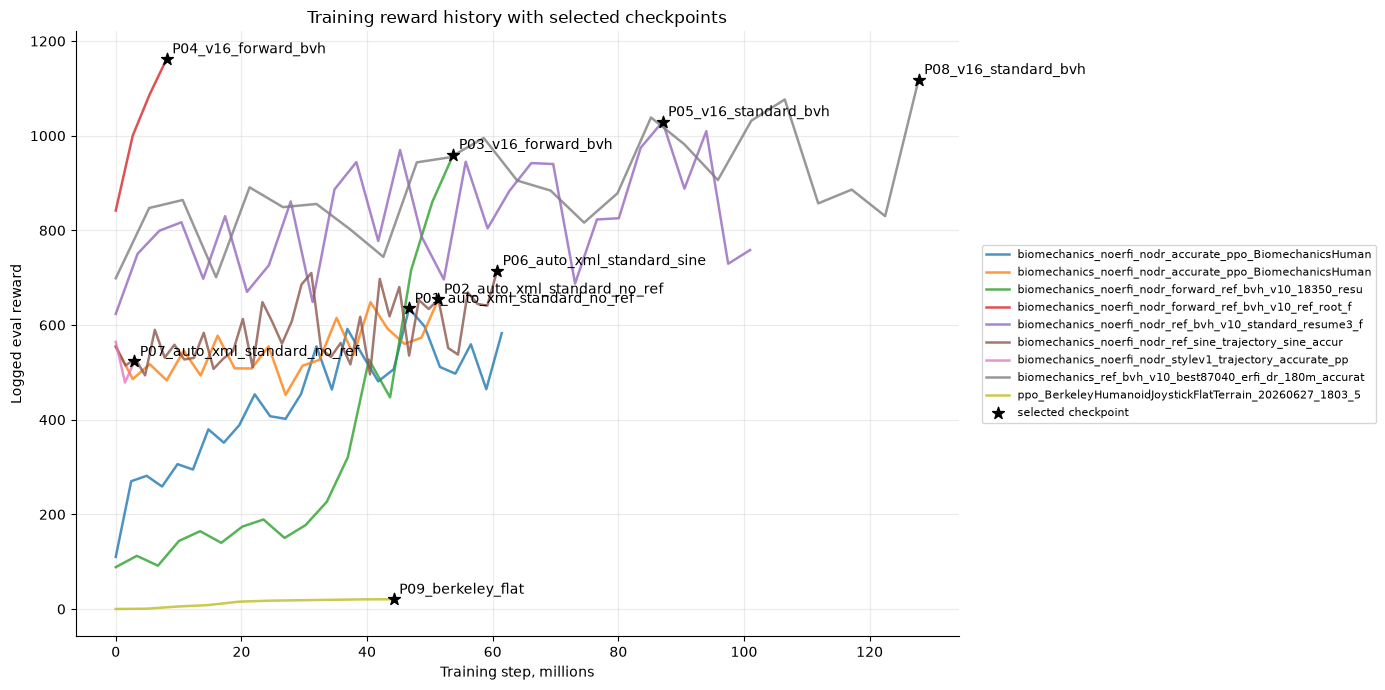

In [39]:
if training_history.empty or "reward" not in training_history:
    display(Markdown("Nema parsirane trening istorije sa `reward` kolonom."))
else:
    history_plot = training_history.copy()
    history_plot["step_m"] = history_plot["step"] / 1_000_000

    fig, ax = plt.subplots(figsize=(14, 7))
    for run_name, group in history_plot.groupby("run_name", sort=False):
        ax.plot(group["step_m"], group["reward"], linewidth=1.8, alpha=0.8, label=run_name[:55])

    best_points = selected_checkpoints.dropna(subset=["training_reward"]).copy()
    best_points["step_m"] = best_points["checkpoint_step"] / 1_000_000
    ax.scatter(
        best_points["step_m"],
        best_points["training_reward"],
        s=80,
        marker="*",
        color="black",
        label="selected checkpoint",
        zorder=5,
    )
    for _, row in best_points.iterrows():
        ax.annotate(row["policy_id"], (row["step_m"], row["training_reward"]), xytext=(4, 4), textcoords="offset points")

    ax.set_title("Training reward history with selected checkpoints")
    ax.set_xlabel("Training step, millions")
    ax.set_ylabel("Logged eval reward")
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8)
    plt.tight_layout()
    plt.show()

<!-- NOTEBOOK_TOP3_TRAINING_REWARD -->
### Top 3 po logged training reward-u

| policy_id | policy_type | checkpoint_step | training_reward | command_profile | reference_gait |
| --- | --- | --- | --- | --- | --- |
| P04_v16_forward_bvh | biomechanics | 8110080 | 1162 | forward | bvh |
| P08_v16_standard_bvh | biomechanics | 127795200 | 1119 | standard | bvh |
| P05_v16_standard_bvh | biomechanics | 87040000 | 1030 | standard | bvh |

Zakljucak: reward history je kontekst, ne finalni dokaz kvaliteta.


In [40]:
if not training_history.empty and "reward" in training_history:
    best_logged = (
        training_history.sort_values("reward", ascending=False)
        .groupby("run_name", as_index=False)
        .head(1)
        .sort_values("reward", ascending=False)
    )
    display(best_logged[["run_name", "step", "reward"]].reset_index(drop=True))

,run_name,step,reward
0,biomechanics_noerfi_nodr_forward_ref_bvh_v10_ref_root_foot_gate_accurate_ppo_BiomechanicsHumanJoystickStandard_20260621_1736_8m_seed7_re...,8110080,1162.4832
1,biomechanics_ref_bvh_v10_best87040_erfi_dr_180m_accurate_ppo_BiomechanicsHumanJoystickStandard_20260625_2136_180m_seed7_running,127795200,1118.5432
2,biomechanics_noerfi_nodr_ref_bvh_v10_standard_resume3_from_29286400_100m_accurate_ppo_BiomechanicsHumanJoystickStandard_20260625_0018_10...,87040000,1029.5856
3,biomechanics_noerfi_nodr_forward_ref_bvh_v10_18350_resume_forward_accurate_ppo_BiomechanicsHumanJoystickStandard_20260621_0254_80m_seed7...,53739520,960.2457
4,biomechanics_noerfi_nodr_ref_sine_trajectory_sine_accurate_ppo_BiomechanicsHumanJoystickStandard_20260616_2321_60m_seed7_rew_714p9127_be...,60702720,714.9127
5,biomechanics_noerfi_nodr_accurate_ppo_BiomechanicsHumanJoystickStandard_20260616_0006_50m_seed7_rew_654p7552_best_654p7552_s,51363840,654.7552
6,biomechanics_noerfi_nodr_accurate_ppo_BiomechanicsHumanJoystickStandard_20260615_1300_70m_seed7_running,46694400,635.1440
7,biomechanics_noerfi_nodr_stylev1_trajectory_accurate_ppo_BiomechanicsHumanJoystickStandard_20260616_2241_70m_seed7_running,0,564.6565
8,ppo_BerkeleyHumanoidJoystickFlatTerrain_20260627_1803_50m_seed7,44236800,20.6182


## 5. Pokreni ili ucitaj rollout analizu

Glavna celija: ucitava CSV cache ili pokrece rollout analizu.

In [41]:
tables = wa.run_analysis(
    runs_dir=RUNS_DIR,
    output_dir=OUTPUT_DIR,
    scenarios=SCENARIOS,
    seeds=SEEDS,
    steps_per_scenario=STEPS_PER_SCENARIO,
    force=FORCE_RECOMPUTE,
)

for table_name, table in tables.items():
    print(f"{table_name:22s} rows={len(table):8d} cols={len(table.columns):4d}")

Loading cached analysis from c:\Users\aleks\Desktop\Aleksie kerefeke\master\RS projekat - RL politika ucenja joystick\mujoco-bipedal-joystick-walker\analysis_outputs
selected_checkpoints   rows=       9 cols=  12
training_history       rows=     175 cols=  26
rollout_steps          rows=   54000 cols= 469
episode_metrics        rows=     205 cols=  43
trial_metrics          rows=     108 cols=  25
policy_metrics         rows=      63 cols=  35
actuator_metrics       rows=    1620 cols=  11


In [42]:
selected = tables.get("selected_checkpoints", selected_checkpoints)
history = tables.get("training_history", training_history)
steps = tables["rollout_steps"]
episode_metrics = tables["episode_metrics"]
trial_metrics = tables["trial_metrics"]
policy_metrics = tables["policy_metrics"]
actuator_metrics = tables["actuator_metrics"]

expected_rows = len(selected) * len(SCENARIOS) * len(SEEDS) * STEPS_PER_SCENARIO
display(
    pd.DataFrame(
        [
            {"check": "expected rollout rows", "value": expected_rows},
            {"check": "actual rollout rows", "value": len(steps)},
            {"check": "policies", "value": steps["policy_id"].nunique()},
            {"check": "scenarios", "value": steps["scenario"].nunique()},
            {"check": "seeds", "value": steps["seed"].nunique()},
            {"check": "falls", "value": int(steps["done"].sum())},
        ]
    )
)

,check,value
0,expected rollout rows,54000
1,actual rollout rows,54000
2,policies,9
3,scenarios,6
4,seeds,2
5,falls,97


## 6. Pomocne funkcije za prikaz

In [43]:
def display_table(title: str, table: pd.DataFrame, rows: int = 20) -> None:
    """Display a titled table without truncating important context."""
    display(Markdown(f"### {title}"))
    display(table.head(rows))


def metric_matrix(
    table: pd.DataFrame,
    value: str,
    index: str = "policy_id",
    columns: str = "scenario",
    aggfunc: str = "mean",
) -> pd.DataFrame:
    """Create a policy-by-scenario matrix for heatmaps."""
    return table.pivot_table(index=index, columns=columns, values=value, aggfunc=aggfunc)


def plot_horizontal_bar(
    table: pd.DataFrame,
    x: str,
    y: str = "policy_id",
    title: str | None = None,
    color: str = "#2f6f9f",
) -> None:
    """Plot a sorted horizontal bar chart."""
    plot_data = table.sort_values(x, ascending=True)
    fig, ax = plt.subplots(figsize=(12, max(4, 0.45 * len(plot_data))))
    ax.barh(plot_data[y], plot_data[x], color=color, alpha=0.9)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(title or x)
    for value, label in zip(plot_data[x], plot_data[y], strict=False):
        if pd.notna(value):
            ax.text(value, label, f" {value:.3f}", va="center", fontsize=9)
    plt.tight_layout()
    plt.show()


def plot_heatmap(
    matrix: pd.DataFrame,
    title: str,
    cmap: str = "viridis",
    fmt: str = ".2f",
) -> None:
    """Plot a compact annotated heatmap using only matplotlib."""
    matrix = matrix.copy()
    fig_width = max(8, 1.35 * len(matrix.columns))
    fig_height = max(4.5, 0.5 * len(matrix.index))
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    image = ax.imshow(matrix.to_numpy(dtype=float), aspect="auto", cmap=cmap)
    ax.set_xticks(np.arange(len(matrix.columns)), labels=matrix.columns, rotation=35, ha="right")
    ax.set_yticks(np.arange(len(matrix.index)), labels=matrix.index)
    ax.set_title(title)
    for row_index in range(len(matrix.index)):
        for column_index in range(len(matrix.columns)):
            value = matrix.iloc[row_index, column_index]
            label = "nan" if pd.isna(value) else format(value, fmt)
            ax.text(column_index, row_index, label, ha="center", va="center", color="white", fontsize=8)
    fig.colorbar(image, ax=ax, fraction=0.025, pad=0.02)
    plt.tight_layout()
    plt.show()


def label_scatter_points(ax: plt.Axes, table: pd.DataFrame, x: str, y: str, label: str = "policy_id") -> None:
    """Annotate scatter points with policy IDs."""
    for _, row in table.iterrows():
        ax.annotate(str(row[label]), (row[x], row[y]), xytext=(5, 4), textcoords="offset points", fontsize=8)


def compact_policy_name(policy_id: str) -> str:
    """Shorten policy IDs for dense chart labels."""
    return policy_id.replace("auto_xml_", "").replace("standard_", "std_")

## 7. Rang lista najboljih politika hoda

In [44]:
leaderboard = (
    policy_metrics.loc[policy_metrics["scenario"].eq("IN_DISTRIBUTION")]
    .sort_values("composite_score", ascending=False)
    .reset_index(drop=True)
)
leaderboard["rank"] = np.arange(1, len(leaderboard) + 1)

leaderboard_columns = [
    "rank",
    "policy_id",
    "policy_type",
    "checkpoint_step",
    "composite_score",
    "mean_first_fall_survival_fraction",
    "fall_rate_per_1000_steps",
    "tracking_rmse",
    "mean_torso_up",
    "mean_action_rate_norm",
    "mean_mechanical_power_abs",
]
display_table("In-distribution policy leaderboard", leaderboard[leaderboard_columns], rows=len(leaderboard))

### In-distribution policy leaderboard

,rank,policy_id,policy_type,checkpoint_step,composite_score,mean_first_fall_survival_fraction,fall_rate_per_1000_steps,tracking_rmse,mean_torso_up,mean_action_rate_norm,mean_mechanical_power_abs
0,1,P08_v16_standard_bvh,biomechanics,127795200,0.7490,1.0000,0.0000,0.1618,0.9416,42.0196,251.7894
1,2,P09_berkeley_flat,berkeley,44236800,0.6092,0.9502,1.3333,0.5778,0.9888,27.8262,55.0472
2,3,P04_v16_forward_bvh,biomechanics,8110080,0.6043,0.9307,0.3333,0.2604,0.9414,34.4703,212.6142
3,4,P05_v16_standard_bvh,biomechanics,87040000,0.5620,0.9028,0.8333,0.3229,0.9659,37.9780,229.5472
4,5,P03_v16_forward_bvh,biomechanics,53739520,0.5582,0.9567,0.6667,0.3697,0.9332,32.8065,207.1853
5,6,P06_auto_xml_standard_sine,biomechanics,60702720,0.5081,0.8460,1.0000,0.1741,0.9466,37.3925,190.4017
6,7,P02_auto_xml_standard_no_ref,biomechanics,51363840,0.3763,0.7805,1.3333,0.2079,0.9448,34.8924,190.3790
7,8,P07_auto_xml_standard_no_ref,biomechanics,2949120,0.3161,0.8113,1.3333,0.2704,0.9262,36.5922,200.1966
8,9,P01_auto_xml_standard_no_ref,biomechanics,46694400,0.2658,0.7972,1.3333,0.3249,0.9287,35.5949,192.3938


In [45]:
if not leaderboard.empty:
    winner = leaderboard.iloc[0]
    summary = f"""
### Automatski rezime

- Najbolji in-distribution policy: **{winner['policy_id']}**.
- Composite score: **{winner['composite_score']:.3f}**.
- Survival fraction do prvog pada: **{winner['mean_first_fall_survival_fraction']:.3f}**.
- Tracking RMSE: **{winner['tracking_rmse']:.3f}**.
- Mean torso up: **{winner['mean_torso_up']:.3f}**.
- Mean action rate norm: **{winner['mean_action_rate_norm']:.3f}**.
"""
    display(Markdown(summary))


### Automatski rezime

- Najbolji in-distribution policy: **P08_v16_standard_bvh**.
- Composite score: **0.749**.
- Survival fraction do prvog pada: **1.000**.
- Tracking RMSE: **0.162**.
- Mean torso up: **0.942**.
- Mean action rate norm: **42.020**.


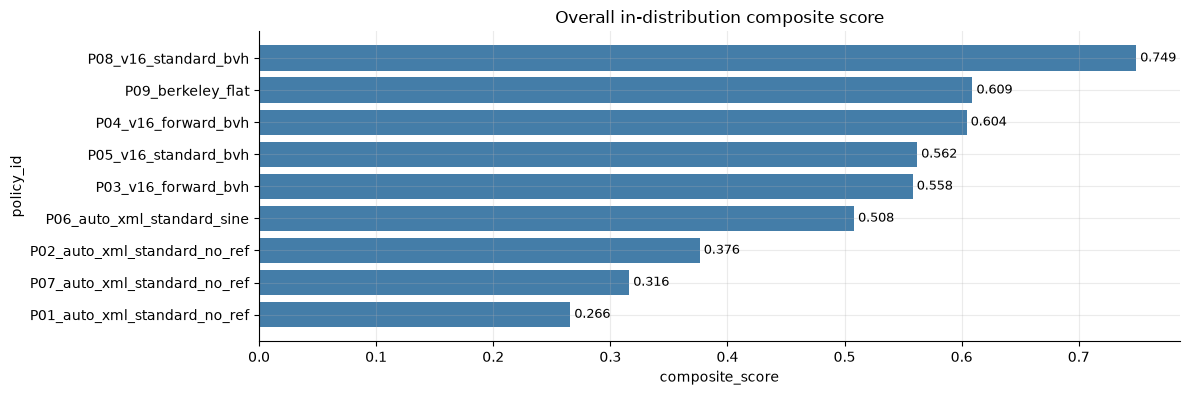

In [46]:
plot_horizontal_bar(
    leaderboard,
    x="composite_score",
    title="Overall in-distribution composite score",
    color="#2f6f9f",
)

<!-- NOTEBOOK_TOP3_COMPOSITE -->
### Top 3 po composite score-u

| rank | policy_id | policy_type | composite_score | mean_first_fall_survival_fraction | tracking_rmse | mean_torso_up | mean_action_rate_norm |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 1 | P08_v16_standard_bvh | biomechanics | 0.7490 | 1.0000 | 0.1618 | 0.9416 | 42.0196 |
| 2 | P09_berkeley_flat | berkeley | 0.6092 | 0.9502 | 0.5778 | 0.9888 | 27.8262 |
| 3 | P04_v16_forward_bvh | biomechanics | 0.6043 | 0.9307 | 0.2604 | 0.9414 | 34.4703 |

Zakljucak: ovo je glavni kratki ranking.


Composite score = survival + tracking + posture + smoothness. Koristi se za brz ranking.

## 8. Scenario matrix

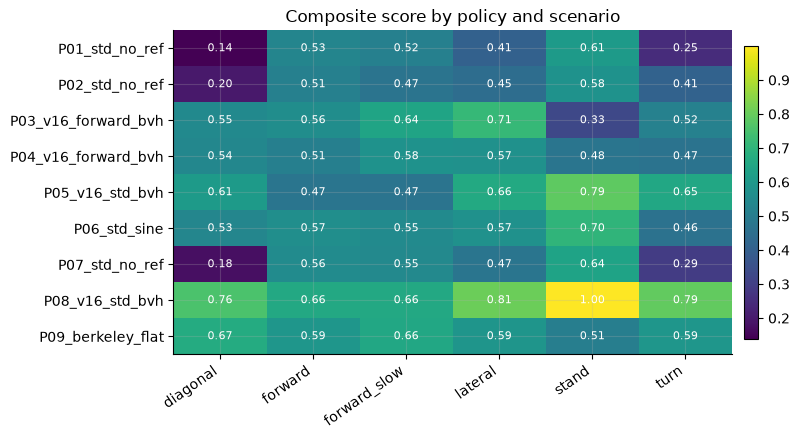

In [47]:
scenario_metrics = policy_metrics.loc[~policy_metrics["scenario"].eq("IN_DISTRIBUTION")].copy()
scenario_metrics["policy_label"] = scenario_metrics["policy_id"].map(compact_policy_name)

score_matrix = metric_matrix(scenario_metrics, value="composite_score", index="policy_label")
plot_heatmap(score_matrix, "Composite score by policy and scenario", cmap="viridis", fmt=".2f")

<!-- NOTEBOOK_TOP3_SCENARIO_SCORE -->
### Top 3 kroz sve scenarije

| policy_id | policy_type | mean_composite_score | worst_composite_score | mean_tracking_rmse | mean_fall_rate |
| --- | --- | --- | --- | --- | --- |
| P08_v16_standard_bvh | biomechanics | 0.7785 | 0.6579 | 0.1470 | 0.0000 |
| P05_v16_standard_bvh | biomechanics | 0.6097 | 0.4698 | 0.2656 | 0.8333 |
| P09_berkeley_flat | berkeley | 0.6008 | 0.5082 | 0.5682 | 1.3333 |

Zakljucak: pogledaj top redove; oni su najkorisniji za prezentaciju.


In [48]:
scenario_leaders = (
    scenario_metrics.sort_values(["scenario", "composite_score"], ascending=[True, False])
    .groupby("scenario", as_index=False)
    .head(3)
    .loc[:, [
        "scenario",
        "policy_id",
        "policy_type",
        "composite_score",
        "tracking_rmse",
        "fall_rate_per_1000_steps",
        "mean_torso_up",
        "mean_action_rate_norm",
    ]]
)
display_table("Top 3 policies per scenario", scenario_leaders, rows=len(scenario_leaders))

### Top 3 policies per scenario

,scenario,policy_id,policy_type,composite_score,tracking_rmse,fall_rate_per_1000_steps,mean_torso_up,mean_action_rate_norm
9,diagonal,P08_v16_standard_bvh,biomechanics,0.7551,0.1985,0.0000,0.9305,51.0225
10,diagonal,P09_berkeley_flat,berkeley,0.6680,0.5004,1.0000,0.9904,26.9287
11,diagonal,P05_v16_standard_bvh,biomechanics,0.6096,0.2141,0.0000,0.9548,49.4440
18,forward,P08_v16_standard_bvh,biomechanics,0.6579,0.1611,0.0000,0.9326,49.4697
19,forward,P09_berkeley_flat,berkeley,0.5920,0.4262,1.0000,0.9909,27.2942
20,forward,P06_auto_xml_standard_sine,biomechanics,0.5658,0.0794,0.0000,0.9794,59.1138
27,forward_slow,P08_v16_standard_bvh,biomechanics,0.6586,0.1328,0.0000,0.9252,49.5313
28,forward_slow,P09_berkeley_flat,berkeley,0.6569,0.5493,1.0000,0.9909,28.0770
29,forward_slow,P03_v16_forward_bvh,biomechanics,0.6422,0.1995,0.0000,0.9316,32.5561
36,lateral,P08_v16_standard_bvh,biomechanics,0.8074,0.1486,0.0000,0.9446,49.8575


In [49]:
overall_scenario_score = (
    scenario_metrics.groupby(["policy_id", "policy_type"], as_index=False)
    .agg(
        mean_composite_score=("composite_score", "mean"),
        worst_composite_score=("composite_score", "min"),
        mean_tracking_rmse=("tracking_rmse", "mean"),
        mean_fall_rate=("fall_rate_per_1000_steps", "mean"),
        mean_survival=("mean_first_fall_survival_fraction", "mean"),
        mean_power=("mean_mechanical_power_abs", "mean"),
    )
    .sort_values(["mean_composite_score", "worst_composite_score"], ascending=False)
    .reset_index(drop=True)
)
overall_scenario_score["rank"] = np.arange(1, len(overall_scenario_score) + 1)
display_table("Mean score across all explicit scenarios", overall_scenario_score, rows=len(overall_scenario_score))

### Mean score across all explicit scenarios

,policy_id,policy_type,mean_composite_score,worst_composite_score,mean_tracking_rmse,mean_fall_rate,mean_survival,mean_power,rank
0,P08_v16_standard_bvh,biomechanics,0.7785,0.6579,0.1470,0.0000,1.0000,251.7894,1
1,P05_v16_standard_bvh,biomechanics,0.6097,0.4698,0.2656,0.8333,0.9028,229.5472,2
2,P09_berkeley_flat,berkeley,0.6008,0.5082,0.5682,1.3333,0.9502,55.0472,3
3,P06_auto_xml_standard_sine,biomechanics,0.5658,0.4644,0.1220,1.0000,0.8460,190.4017,4
4,P03_v16_forward_bvh,biomechanics,0.5516,0.3280,0.4494,4.5000,0.9567,216.8129,5
5,P04_v16_forward_bvh,biomechanics,0.5238,0.4666,0.4138,4.5000,0.9307,212.4978,6
6,P07_auto_xml_standard_no_ref,biomechanics,0.4467,0.1756,0.1910,1.3333,0.8113,200.1966,7
7,P02_auto_xml_standard_no_ref,biomechanics,0.4369,0.1996,0.1562,1.3333,0.7805,190.3790,8
8,P01_auto_xml_standard_no_ref,biomechanics,0.4083,0.1399,0.2247,1.3333,0.7972,192.3938,9


## 9. Survival i padovi

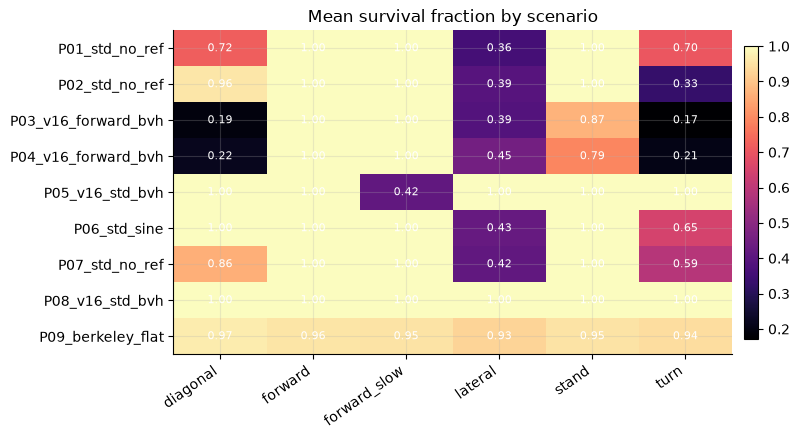

In [50]:
survival_by_scenario = (
    trial_metrics.groupby(["policy_id", "scenario"], as_index=False)
    .agg(
        mean_survival_fraction=("survival_fraction", "mean"),
        falls=("falls", "sum"),
        first_fall_time_s=("first_fall_time_s", "mean"),
    )
)
survival_by_scenario["policy_label"] = survival_by_scenario["policy_id"].map(compact_policy_name)

survival_matrix = metric_matrix(survival_by_scenario, value="mean_survival_fraction", index="policy_label")
plot_heatmap(survival_matrix, "Mean survival fraction by scenario", cmap="magma", fmt=".2f")

<!-- NOTEBOOK_TOP3_SURVIVAL -->
### Top 3 po survival fraction-u

| policy_id | policy_type | mean_survival_fraction | total_falls | min_first_fall_time_s | mean_min_torso_up |
| --- | --- | --- | --- | --- | --- |
| P08_v16_standard_bvh | biomechanics | 1.0000 | 0.0000 | 10.0000 | 0.8564 |
| P09_berkeley_flat | berkeley | 0.9502 | 8.0000 | 9.0600 | 0.2906 |
| P05_v16_standard_bvh | biomechanics | 0.9028 | 5.0000 | 2.6800 | 0.8883 |

Zakljucak: manje padova je vaznije od lepog reward broja.


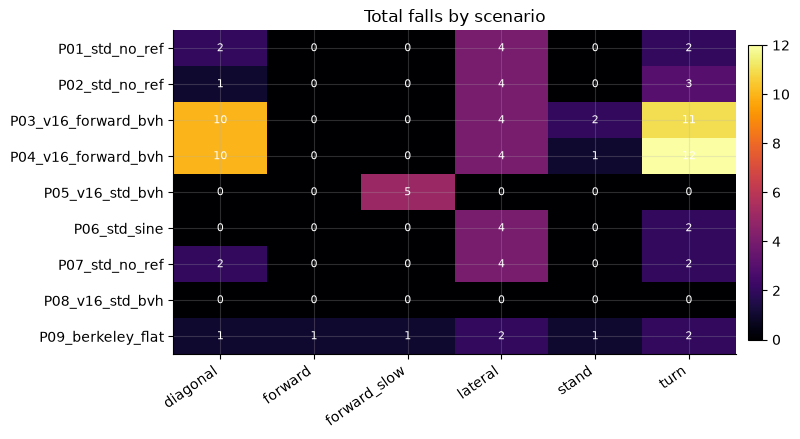

In [51]:
fall_matrix = metric_matrix(survival_by_scenario, value="falls", index="policy_label", aggfunc="sum")
plot_heatmap(fall_matrix, "Total falls by scenario", cmap="inferno", fmt=".0f")

<!-- NOTEBOOK_TOP3_LEAST_FALLS -->
### Top 3 sa najmanje padova

| policy_id | policy_type | total_falls | mean_survival_fraction | min_first_fall_time_s | mean_min_torso_up |
| --- | --- | --- | --- | --- | --- |
| P08_v16_standard_bvh | biomechanics | 0.0000 | 1.0000 | 10.0000 | 0.8564 |
| P05_v16_standard_bvh | biomechanics | 5.0000 | 0.9028 | 2.6800 | 0.8883 |
| P09_berkeley_flat | berkeley | 8.0000 | 0.9502 | 9.0600 | 0.2906 |

Zakljucak: manje padova je vaznije od lepog reward broja.


In [52]:
fall_summary = (
    trial_metrics.groupby(["policy_id", "policy_type"], as_index=False)
    .agg(
        total_falls=("falls", "sum"),
        mean_survival_fraction=("survival_fraction", "mean"),
        min_first_fall_time_s=("first_fall_time_s", "min"),
        mean_min_root_height=("min_root_height", "mean"),
        mean_min_torso_up=("min_torso_up", "mean"),
    )
    .sort_values(["total_falls", "mean_survival_fraction"], ascending=[True, False])
)
display_table("Fall robustness summary", fall_summary, rows=len(fall_summary))

### Fall robustness summary

,policy_id,policy_type,total_falls,mean_survival_fraction,min_first_fall_time_s,mean_min_root_height,mean_min_torso_up
7,P08_v16_standard_bvh,biomechanics,0.0000,1.0000,10.0000,1.3938,0.8564
4,P05_v16_standard_bvh,biomechanics,5.0000,0.9028,2.6800,1.3266,0.8883
5,P06_auto_xml_standard_sine,biomechanics,6.0000,0.8460,3.8000,1.2326,0.8394
8,P09_berkeley_flat,berkeley,8.0000,0.9502,9.0600,0.2309,0.2906
6,P07_auto_xml_standard_no_ref,biomechanics,8.0000,0.8113,3.8600,1.1607,0.7928
0,P01_auto_xml_standard_no_ref,biomechanics,8.0000,0.7972,3.5400,1.1566,0.7888
1,P02_auto_xml_standard_no_ref,biomechanics,8.0000,0.7805,3.0800,1.1999,0.8220
3,P04_v16_forward_bvh,biomechanics,27.0000,0.6115,1.5400,1.0963,0.7272
2,P03_v16_forward_bvh,biomechanics,27.0000,0.6042,1.4800,1.0561,0.7227


## 10. Command tracking

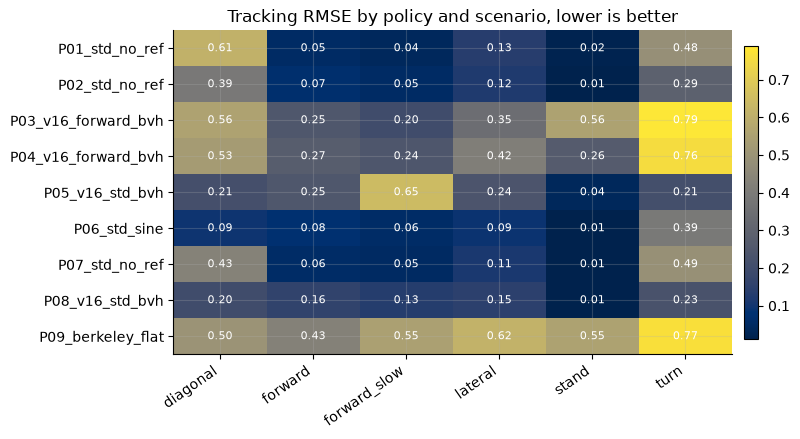

In [53]:
tracking_matrix = metric_matrix(scenario_metrics.assign(policy_label=scenario_metrics["policy_id"].map(compact_policy_name)), value="tracking_rmse", index="policy_label")
plot_heatmap(tracking_matrix, "Tracking RMSE by policy and scenario, lower is better", cmap="cividis", fmt=".2f")

<!-- NOTEBOOK_TOP3_TRACKING -->
### Top 3 po command tracking-u

| policy_id | policy_type | mean_tracking_rmse | mean_command_failure_rate | mean_horizontal_speed | total_falls |
| --- | --- | --- | --- | --- | --- |
| P06_auto_xml_standard_sine | biomechanics | 0.1179 | 0.0208 | 0.1987 | 6.0000 |
| P02_auto_xml_standard_no_ref | biomechanics | 0.1461 | 0.0487 | 0.2141 | 8.0000 |
| P08_v16_standard_bvh | biomechanics | 0.1467 | 0.1142 | 0.2110 | 0.0000 |

Zakljucak: nizi RMSE znaci bolje pracenje komande.


In [54]:
tracking_details = (
    trial_metrics.groupby(["policy_id", "scenario"], as_index=False)
    .agg(
        tracking_rmse=("tracking_rmse", "mean"),
        command_failure_rate=("command_failure_rate", "mean"),
        mean_horizontal_speed=("mean_horizontal_speed", "mean"),
    )
    .sort_values(["scenario", "tracking_rmse"])
)
display_table("Tracking details", tracking_details, rows=60)

### Tracking details

,policy_id,scenario,tracking_rmse,command_failure_rate,mean_horizontal_speed
30,P06_auto_xml_standard_sine,diagonal,0.0948,0.0070,0.3218
42,P08_v16_standard_bvh,diagonal,0.1983,0.1880,0.3105
24,P05_v16_standard_bvh,diagonal,0.2140,0.1960,0.3139
6,P02_auto_xml_standard_no_ref,diagonal,0.3319,0.1130,0.3470
36,P07_auto_xml_standard_no_ref,diagonal,0.4296,0.1560,0.4217
48,P09_berkeley_flat,diagonal,0.4921,0.4610,0.3455
18,P04_v16_forward_bvh,diagonal,0.5293,0.9960,0.4954
12,P03_v16_forward_bvh,diagonal,0.5572,0.9880,0.5137
0,P01_auto_xml_standard_no_ref,diagonal,0.6118,0.1690,0.4240
1,P01_auto_xml_standard_no_ref,forward,0.0543,0.0100,0.3338


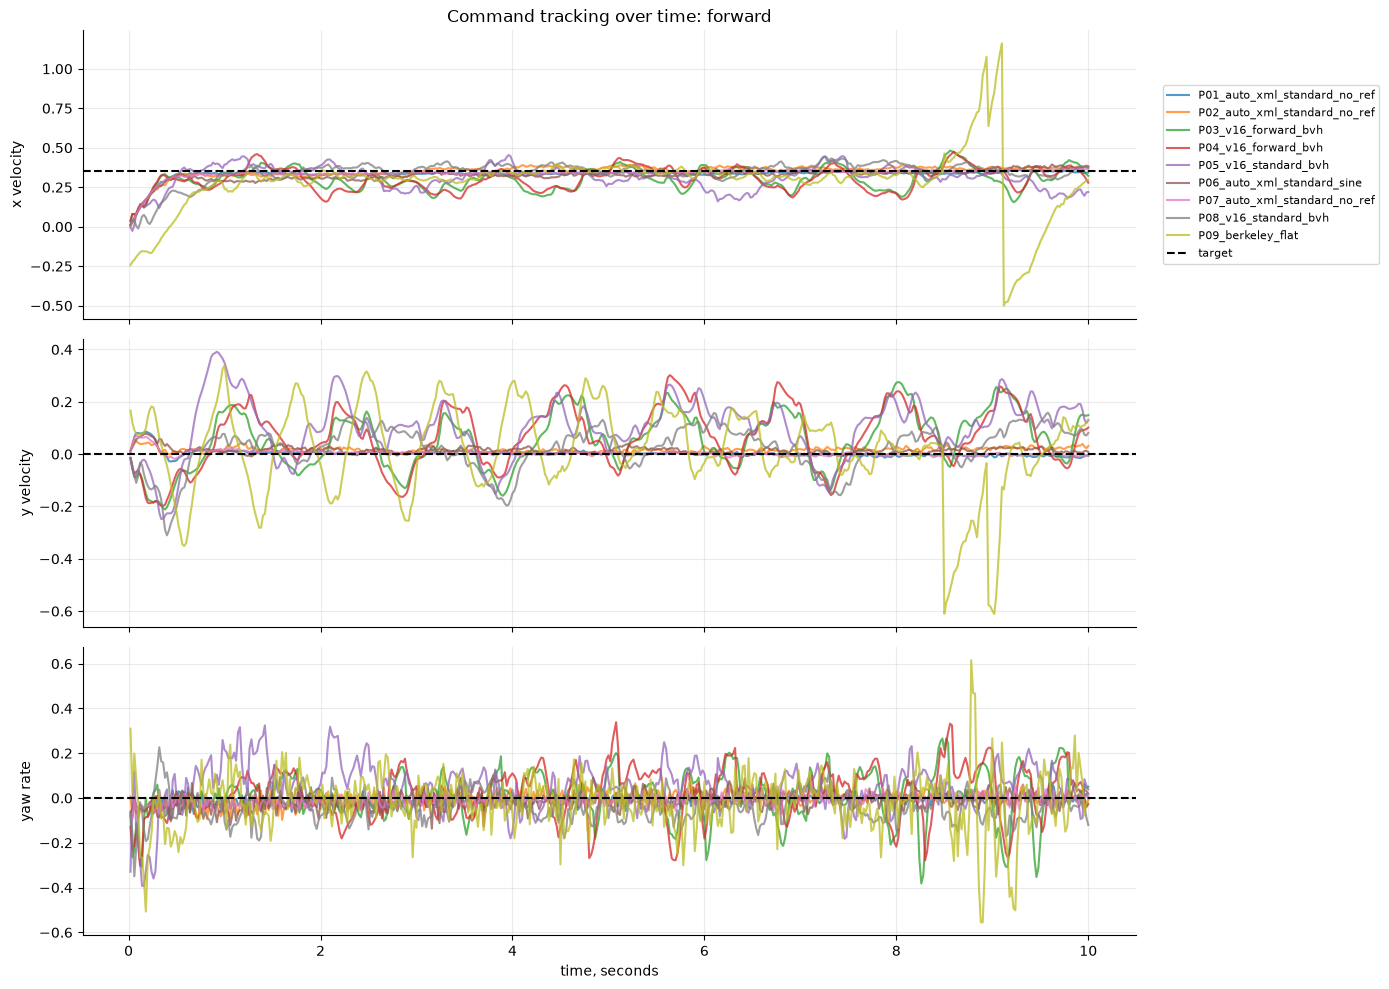

In [55]:
selected_scenario = "forward"
tracking_time = (
    steps.loc[steps["scenario"].eq(selected_scenario)]
    .groupby(["policy_id", "scenario_step"], as_index=False)
    .agg(
        command_x=("command_x", "mean"),
        measured_command_x=("measured_command_x", "mean"),
        command_y=("command_y", "mean"),
        measured_command_y=("measured_command_y", "mean"),
        command_yaw=("command_yaw", "mean"),
        measured_command_yaw=("measured_command_yaw", "mean"),
        time_s=("time_s", "mean"),
    )
)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
for policy_id, group in tracking_time.groupby("policy_id", sort=False):
    axes[0].plot(group["time_s"], group["measured_command_x"], alpha=0.75, label=policy_id)
    axes[1].plot(group["time_s"], group["measured_command_y"], alpha=0.75)
    axes[2].plot(group["time_s"], group["measured_command_yaw"], alpha=0.75)

if not tracking_time.empty:
    axes[0].axhline(tracking_time["command_x"].iloc[0], color="black", linestyle="--", linewidth=1.5, label="target")
    axes[1].axhline(tracking_time["command_y"].iloc[0], color="black", linestyle="--", linewidth=1.5)
    axes[2].axhline(tracking_time["command_yaw"].iloc[0], color="black", linestyle="--", linewidth=1.5)

axes[0].set_title(f"Command tracking over time: {selected_scenario}")
axes[0].set_ylabel("x velocity")
axes[1].set_ylabel("y velocity")
axes[2].set_ylabel("yaw rate")
axes[2].set_xlabel("time, seconds")
axes[0].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8)
plt.tight_layout()
plt.show()

<!-- NOTEBOOK_TOP3_FORWARD_TRACKING_LINE -->
### Top 3 za forward line chart

| policy_id | policy_type | tracking_rmse | command_failure_rate | mean_horizontal_speed | falls |
| --- | --- | --- | --- | --- | --- |
| P01_auto_xml_standard_no_ref | biomechanics | 0.0543 | 0.0100 | 0.3338 | 0.0000 |
| P07_auto_xml_standard_no_ref | biomechanics | 0.0567 | 0.0100 | 0.3397 | 0.0000 |
| P02_auto_xml_standard_no_ref | biomechanics | 0.0681 | 0.0110 | 0.3529 | 0.0000 |

Zakljucak: pogledaj top redove; oni su najkorisniji za prezentaciju.


<!-- FILTERED_TOP4_COMMAND_TRACKING_NOTES -->
### Filtrirani command tracking: samo top 4

| policy_id | policy_type | tracking_rmse | command_failure_rate | mean_horizontal_speed | falls |
| --- | --- | --- | --- | --- | --- |
| P01_auto_xml_standard_no_ref | biomechanics | 0.0543 | 0.0100 | 0.3338 | 0.0000 |
| P07_auto_xml_standard_no_ref | biomechanics | 0.0567 | 0.0100 | 0.3397 | 0.0000 |
| P02_auto_xml_standard_no_ref | biomechanics | 0.0681 | 0.0110 | 0.3529 | 0.0000 |
| P06_auto_xml_standard_sine | biomechanics | 0.0793 | 0.0100 | 0.3303 | 0.0000 |

Zakljucak: nizi RMSE znaci bolje pracenje komande.


,policy_id,policy_type,tracking_rmse,command_failure_rate,mean_horizontal_speed,falls
0,P01_auto_xml_standard_no_ref,biomechanics,0.0543,0.0100,0.3338,0.0000
6,P07_auto_xml_standard_no_ref,biomechanics,0.0567,0.0100,0.3397,0.0000
1,P02_auto_xml_standard_no_ref,biomechanics,0.0681,0.0110,0.3529,0.0000
5,P06_auto_xml_standard_sine,biomechanics,0.0793,0.0100,0.3303,0.0000


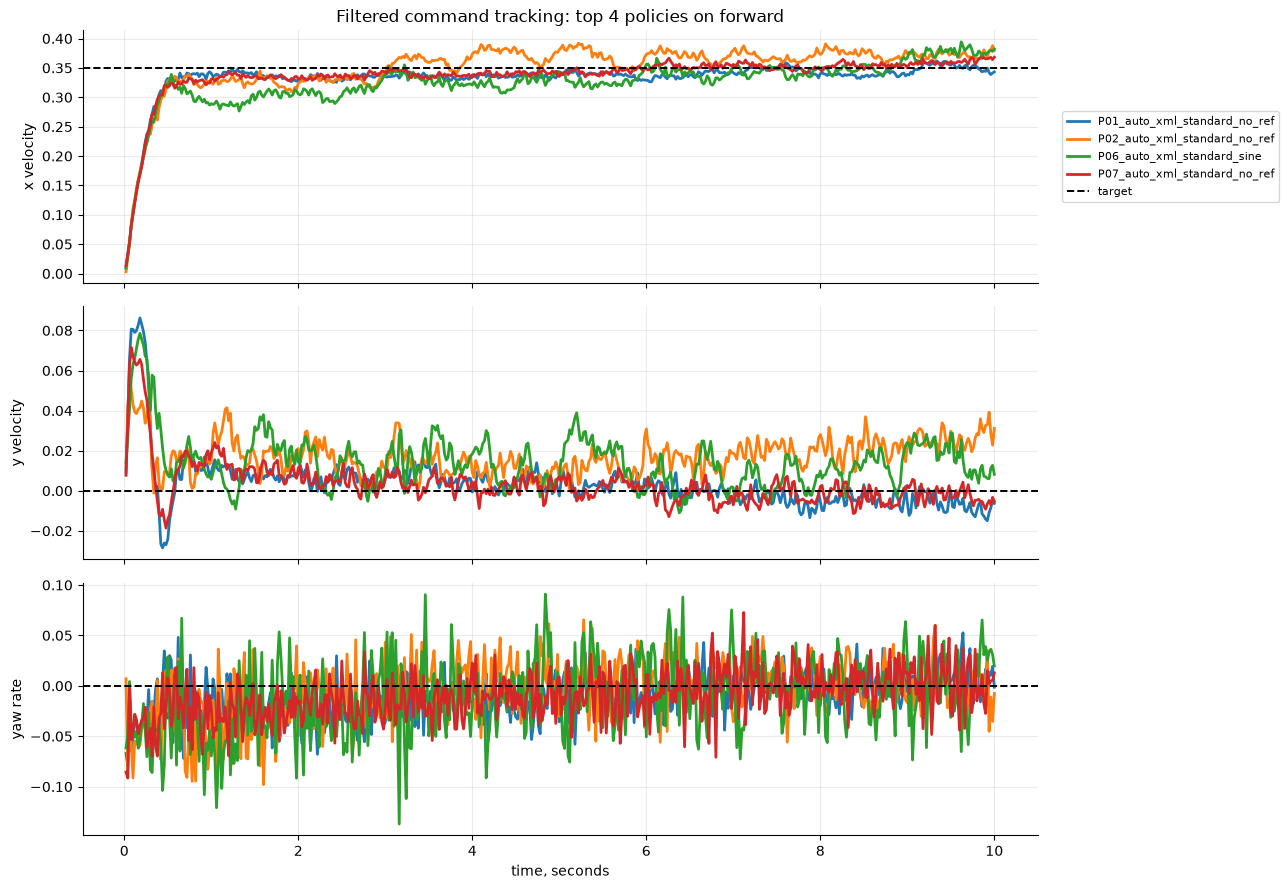

In [56]:
# Filtered command tracking: top 4 policies for the selected scenario.
filtered_scenario = "forward"
filtered_tracking_top4 = (
    trial_metrics.loc[trial_metrics["scenario"].eq(filtered_scenario)]
    .groupby(["policy_id", "policy_type"], as_index=False)
    .agg(
        tracking_rmse=("tracking_rmse", "mean"),
        command_failure_rate=("command_failure_rate", "mean"),
        mean_horizontal_speed=("mean_horizontal_speed", "mean"),
        falls=("falls", "sum"),
    )
    .sort_values(["tracking_rmse", "command_failure_rate", "falls"])
    .head(4)
)
filtered_policies = filtered_tracking_top4["policy_id"].tolist()
display(filtered_tracking_top4)

filtered_tracking_time = (
    steps.loc[
        steps["scenario"].eq(filtered_scenario)
        & steps["policy_id"].isin(filtered_policies)
    ]
    .groupby(["policy_id", "scenario_step"], as_index=False)
    .agg(
        command_x=("command_x", "mean"),
        measured_command_x=("measured_command_x", "mean"),
        command_y=("command_y", "mean"),
        measured_command_y=("measured_command_y", "mean"),
        command_yaw=("command_yaw", "mean"),
        measured_command_yaw=("measured_command_yaw", "mean"),
        time_s=("time_s", "mean"),
    )
)

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
for policy_id, group in filtered_tracking_time.groupby("policy_id", sort=False):
    axes[0].plot(group["time_s"], group["measured_command_x"], linewidth=2.0, label=policy_id)
    axes[1].plot(group["time_s"], group["measured_command_y"], linewidth=2.0, label=policy_id)
    axes[2].plot(group["time_s"], group["measured_command_yaw"], linewidth=2.0, label=policy_id)
if not filtered_tracking_time.empty:
    axes[0].axhline(filtered_tracking_time["command_x"].iloc[0], color="black", linestyle="--", linewidth=1.4, label="target")
    axes[1].axhline(filtered_tracking_time["command_y"].iloc[0], color="black", linestyle="--", linewidth=1.4)
    axes[2].axhline(filtered_tracking_time["command_yaw"].iloc[0], color="black", linestyle="--", linewidth=1.4)
axes[0].set_title(f"Filtered command tracking: top {len(filtered_policies)} policies on {filtered_scenario}")
axes[0].set_ylabel("x velocity")
axes[1].set_ylabel("y velocity")
axes[2].set_ylabel("yaw rate")
axes[2].set_xlabel("time, seconds")
axes[0].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8)
plt.tight_layout()
plt.show()


## 11. Posture / smoothness / energy

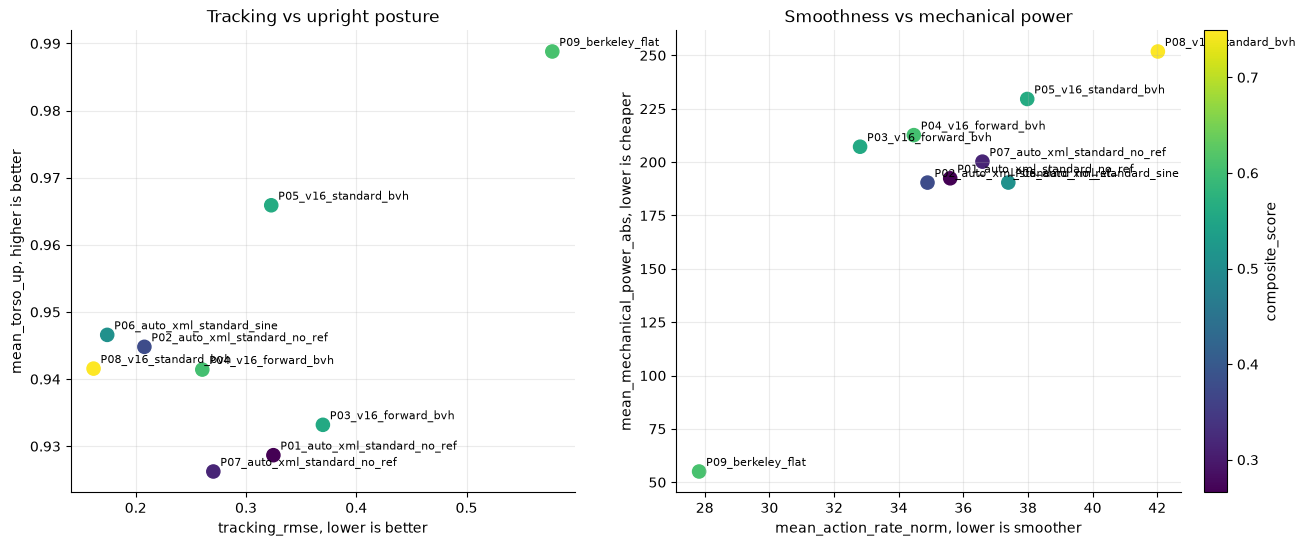

In [57]:
tradeoff = leaderboard.copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].scatter(tradeoff["tracking_rmse"], tradeoff["mean_torso_up"], s=90, c=tradeoff["composite_score"], cmap="viridis")
label_scatter_points(axes[0], tradeoff, "tracking_rmse", "mean_torso_up")
axes[0].set_title("Tracking vs upright posture")
axes[0].set_xlabel("tracking_rmse, lower is better")
axes[0].set_ylabel("mean_torso_up, higher is better")

scatter = axes[1].scatter(
    tradeoff["mean_action_rate_norm"],
    tradeoff["mean_mechanical_power_abs"],
    s=90,
    c=tradeoff["composite_score"],
    cmap="viridis",
)
label_scatter_points(axes[1], tradeoff, "mean_action_rate_norm", "mean_mechanical_power_abs")
axes[1].set_title("Smoothness vs mechanical power")
axes[1].set_xlabel("mean_action_rate_norm, lower is smoother")
axes[1].set_ylabel("mean_mechanical_power_abs, lower is cheaper")

fig.colorbar(scatter, ax=axes, fraction=0.025, pad=0.02, label="composite_score")
plt.show()

<!-- NOTEBOOK_TOP3_TRADEOFF -->
### Top 3 balans tracking/stability/smoothness

| policy_id | policy_type | composite_score | tracking_rmse | mean_torso_up | mean_action_rate_norm | mean_mechanical_power_abs |
| --- | --- | --- | --- | --- | --- | --- |
| P08_v16_standard_bvh | biomechanics | 0.7490 | 0.1618 | 0.9416 | 42.0196 | 251.7894 |
| P09_berkeley_flat | berkeley | 0.6092 | 0.5778 | 0.9888 | 27.8262 | 55.0472 |
| P04_v16_forward_bvh | biomechanics | 0.6043 | 0.2604 | 0.9414 | 34.4703 | 212.6142 |

Zakljucak: nizi RMSE znaci bolje pracenje komande.


In [58]:
diagnostic_columns = [
    "policy_id",
    "scenario",
    "mean_root_height",
    "min_root_height",
    "mean_torso_up",
    "min_torso_up",
    "mean_tilt_angle_rad",
    "mean_action_norm",
    "mean_action_rate_norm",
    "mean_action_saturation_rate",
    "mean_mechanical_power_abs",
    "mean_foot_slip_speed",
]
display_table(
    "Posture and smoothness diagnostics by scenario",
    scenario_metrics[diagnostic_columns].sort_values(["scenario", "mean_torso_up"], ascending=[True, False]),
    rows=80,
)

### Posture and smoothness diagnostics by scenario

,policy_id,scenario,mean_root_height,min_root_height,mean_torso_up,min_torso_up,mean_tilt_angle_rad,mean_action_norm,mean_action_rate_norm,mean_action_saturation_rate,mean_mechanical_power_abs,mean_foot_slip_speed
10,P09_berkeley_flat,diagonal,0.5280,0.2051,0.9904,-0.0706,0.0692,1.5593,26.9287,0.0174,58.7791,0.0000
11,P05_v16_standard_bvh,diagonal,1.4727,1.4268,0.9548,0.8912,0.2838,2.2265,49.4440,0.0646,318.5932,0.2313
13,P04_v16_forward_bvh,diagonal,1.4161,0.8568,0.9310,0.8049,0.3439,2.1941,25.3716,0.0233,236.6860,0.4822
9,P08_v16_standard_bvh,diagonal,1.4585,1.3846,0.9305,0.8337,0.3505,2.1709,51.0225,0.0422,323.6486,0.2094
14,P06_auto_xml_standard_sine,diagonal,1.4350,1.3557,0.9238,0.8086,0.3685,2.0389,48.5604,0.0068,307.1972,0.7801
12,P03_v16_forward_bvh,diagonal,1.4110,0.8590,0.9233,0.7574,0.3638,2.1887,27.8152,0.0149,269.4412,0.5348
17,P01_auto_xml_standard_no_ref,diagonal,1.4014,0.8963,0.8988,0.6133,0.4164,1.9988,40.9608,0.0039,309.2538,0.8209
15,P02_auto_xml_standard_no_ref,diagonal,1.4124,0.9047,0.8956,0.4789,0.4206,2.1586,49.6080,0.0181,339.3433,0.8662
16,P07_auto_xml_standard_no_ref,diagonal,1.3886,0.8799,0.8491,0.3173,0.4987,2.0888,47.5730,0.0106,363.5498,0.9451
23,P01_auto_xml_standard_no_ref,forward,1.4809,1.4640,0.9963,0.9885,0.0769,1.7478,66.9453,0.0003,253.5126,0.7786


## 12. Trajektorije kroz prostor

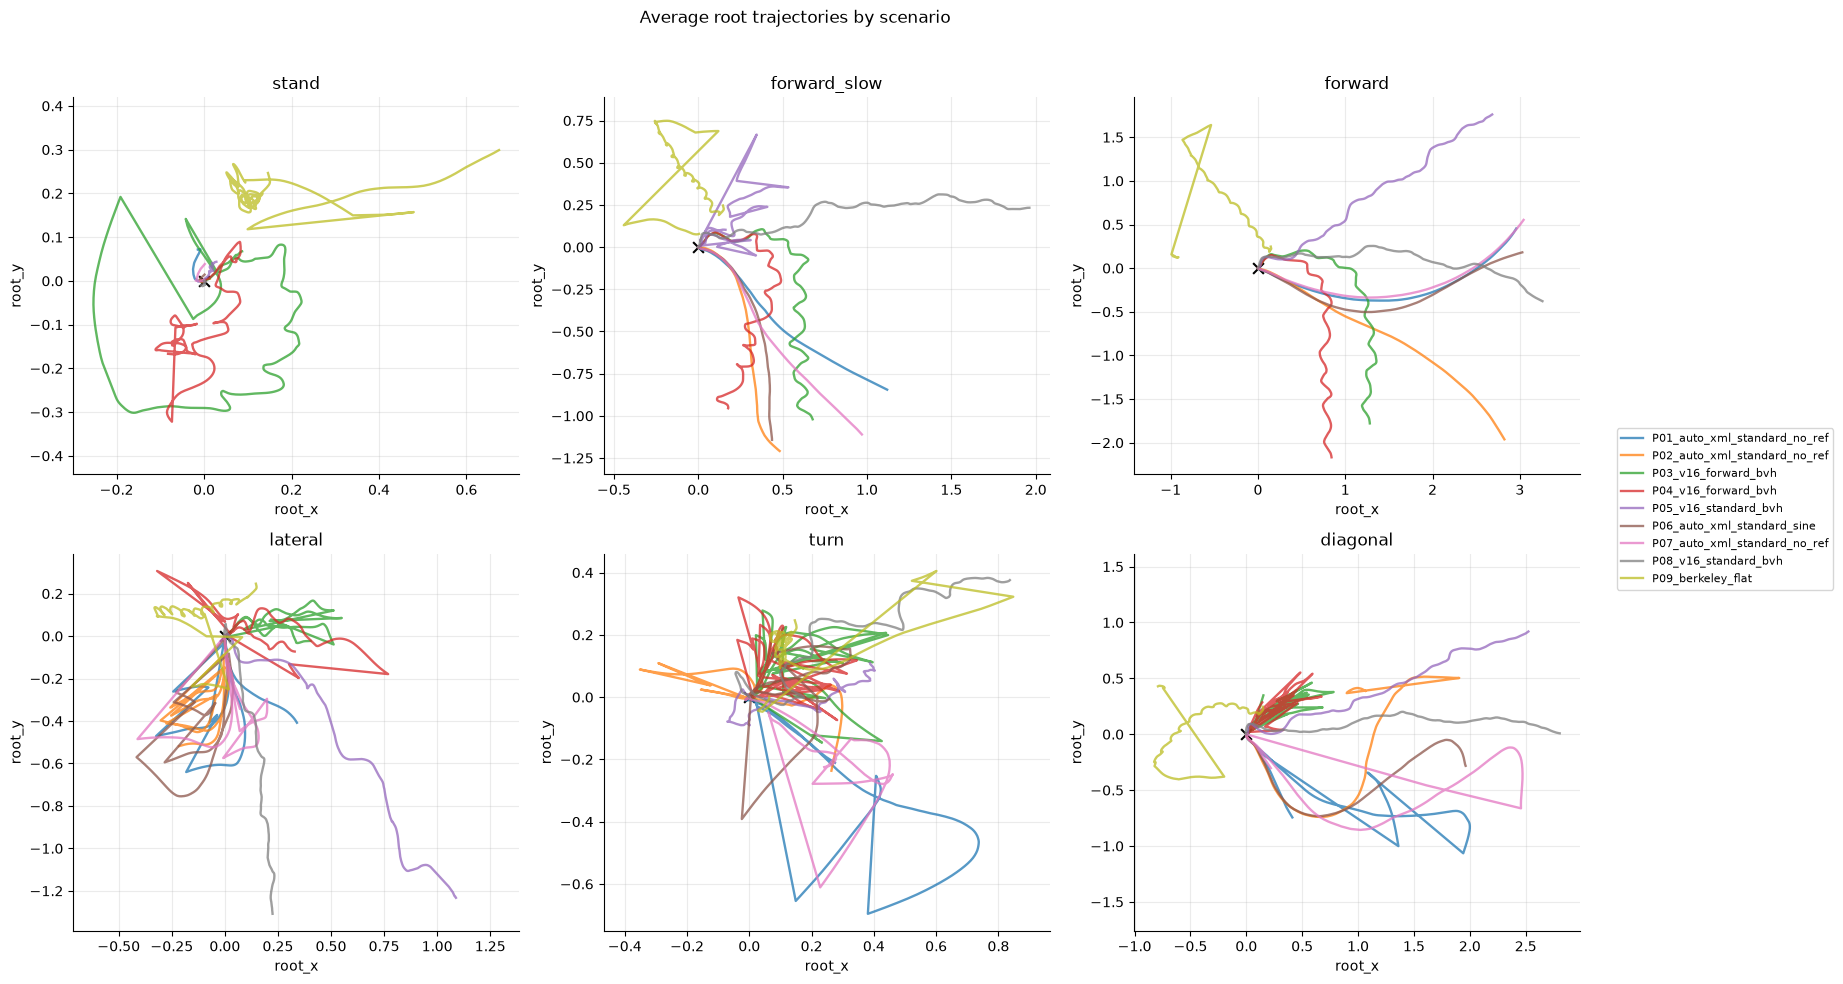

In [59]:
trajectory_summary = (
    steps.groupby(["policy_id", "scenario", "scenario_step"], as_index=False)
    .agg(root_x=("root_x", "mean"), root_y=("root_y", "mean"), root_z=("root_z", "mean"), done=("done", "mean"))
)

plot_scenarios = [name for name in scenario_names if name in trajectory_summary["scenario"].unique()]
cols = 3
rows = int(np.ceil(len(plot_scenarios) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(16, 4.8 * rows), squeeze=False)

for ax, scenario_name in zip(axes.ravel(), plot_scenarios, strict=False):
    subset = trajectory_summary.loc[trajectory_summary["scenario"].eq(scenario_name)]
    for policy_id, group in subset.groupby("policy_id", sort=False):
        ax.plot(group["root_x"], group["root_y"], alpha=0.75, linewidth=1.7, label=policy_id)
    ax.scatter([0], [0], marker="x", color="black", s=60)
    ax.set_title(scenario_name)
    ax.set_xlabel("root_x")
    ax.set_ylabel("root_y")
    ax.axis("equal")

for ax in axes.ravel()[len(plot_scenarios):]:
    ax.axis("off")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=8)
fig.suptitle("Average root trajectories by scenario", y=1.02)
plt.tight_layout()
plt.show()

<!-- NOTEBOOK_TOP3_TRAJECTORY -->
### Top 3 po regularnosti trajektorije

| policy_id | policy_type | mean_trajectory_straightness | mean_displacement_2d | mean_path_length_2d | mean_tracking_rmse |
| --- | --- | --- | --- | --- | --- |
| P01_auto_xml_standard_no_ref | biomechanics | 0.8169 | 1.1355 | 1.3894 | 0.2023 |
| P03_v16_forward_bvh | biomechanics | 0.7727 | 0.6865 | 1.0156 | 0.5327 |
| P07_auto_xml_standard_no_ref | biomechanics | 0.7543 | 1.0405 | 1.3672 | 0.1760 |

Zakljucak: citljivije od punog grafa sa svim politikama.


<!-- FILTERED_TOP4_ROOT_TRAJECTORIES_NOTES -->
### Filtrirane root trajektorije: samo top 4

| policy_id | policy_type | mean_composite_score | worst_composite_score | mean_tracking_rmse | mean_fall_rate |
| --- | --- | --- | --- | --- | --- |
| P08_v16_standard_bvh | biomechanics | 0.7785 | 0.6579 | 0.1470 | 0.0000 |
| P05_v16_standard_bvh | biomechanics | 0.6097 | 0.4698 | 0.2656 | 0.8333 |
| P09_berkeley_flat | berkeley | 0.6008 | 0.5082 | 0.5682 | 1.3333 |
| P06_auto_xml_standard_sine | biomechanics | 0.5658 | 0.4644 | 0.1220 | 1.0000 |

Zakljucak: citljivije od punog grafa sa svim politikama.


,policy_id,policy_type,mean_composite_score,worst_composite_score,mean_tracking_rmse,mean_fall_rate
7,P08_v16_standard_bvh,biomechanics,0.7785,0.6579,0.1470,0.0000
4,P05_v16_standard_bvh,biomechanics,0.6097,0.4698,0.2656,0.8333
8,P09_berkeley_flat,berkeley,0.6008,0.5082,0.5682,1.3333
5,P06_auto_xml_standard_sine,biomechanics,0.5658,0.4644,0.1220,1.0000


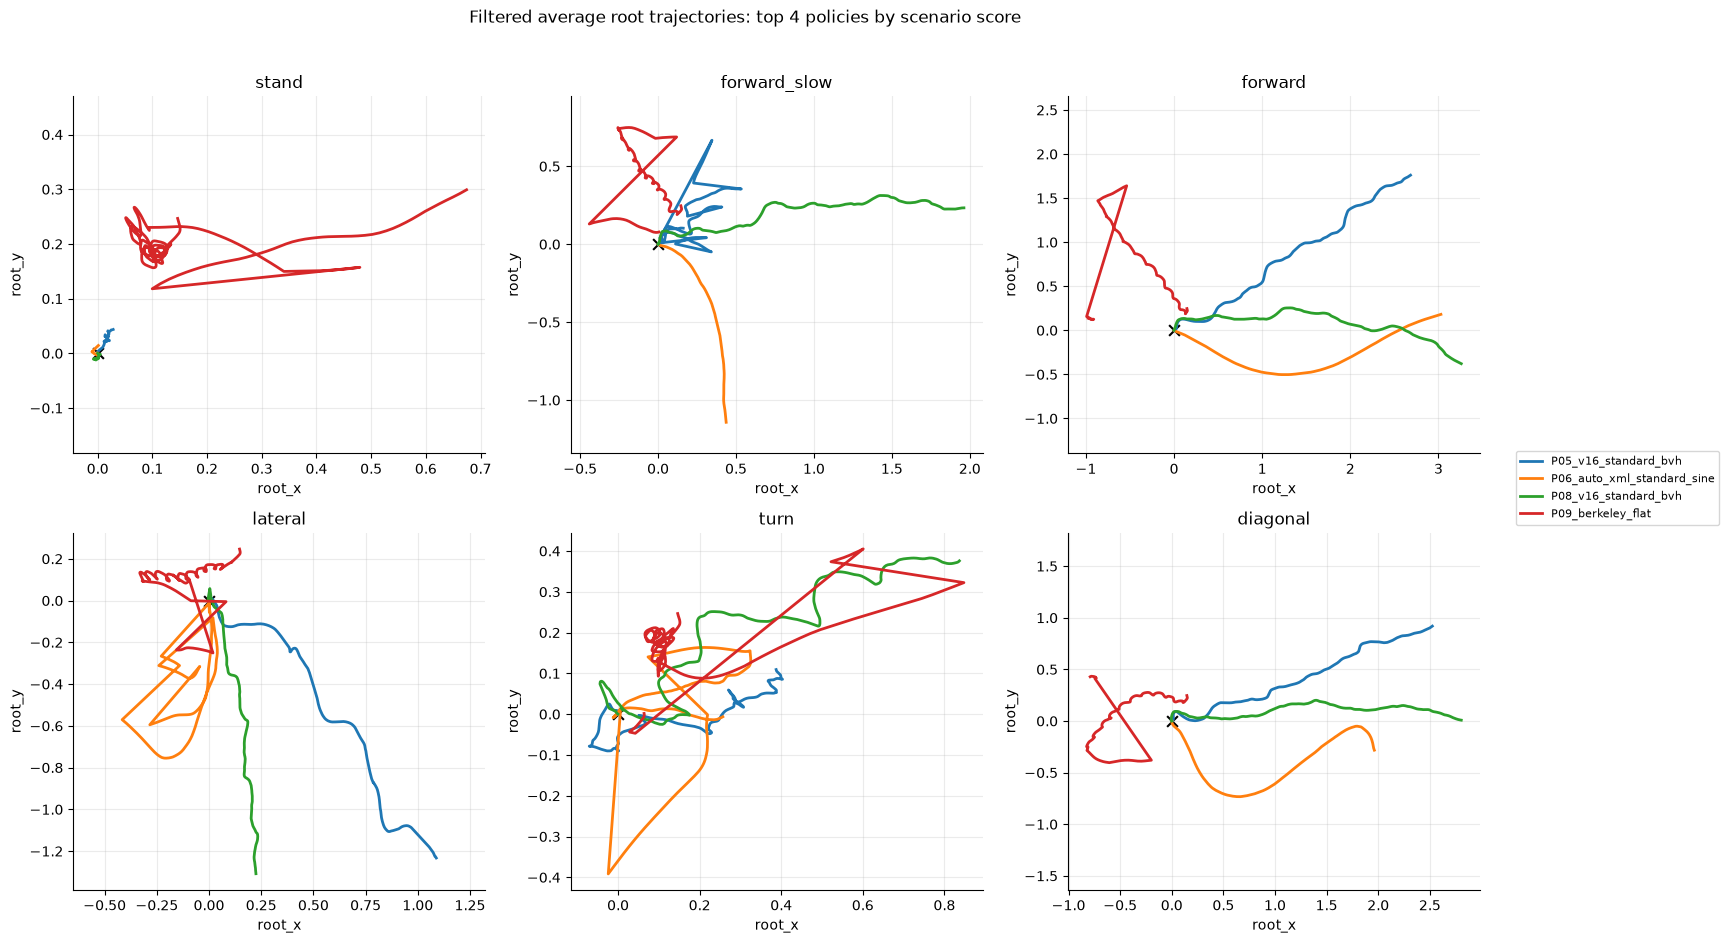

In [60]:
# Filtered root trajectories: top 4 policies by mean scenario composite score.
trajectory_top4 = (
    policy_metrics.loc[~policy_metrics["scenario"].eq("IN_DISTRIBUTION")]
    .groupby(["policy_id", "policy_type"], as_index=False)
    .agg(
        mean_composite_score=("composite_score", "mean"),
        worst_composite_score=("composite_score", "min"),
        mean_tracking_rmse=("tracking_rmse", "mean"),
        mean_fall_rate=("fall_rate_per_1000_steps", "mean"),
    )
    .sort_values(["mean_composite_score", "worst_composite_score"], ascending=[False, False])
    .head(4)
)
filtered_policies = trajectory_top4["policy_id"].tolist()
display(trajectory_top4)

filtered_trajectory_summary = (
    steps.loc[steps["policy_id"].isin(filtered_policies)]
    .groupby(["policy_id", "scenario", "scenario_step"], as_index=False)
    .agg(root_x=("root_x", "mean"), root_y=("root_y", "mean"))
)
plot_scenarios = [name for name in scenario_names if name in filtered_trajectory_summary["scenario"].unique()]
cols = 3
rows = int(np.ceil(len(plot_scenarios) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(15, 4.6 * rows), squeeze=False)
for ax, scenario_name in zip(axes.ravel(), plot_scenarios, strict=False):
    subset = filtered_trajectory_summary.loc[filtered_trajectory_summary["scenario"].eq(scenario_name)]
    for policy_id, group in subset.groupby("policy_id", sort=False):
        ax.plot(group["root_x"], group["root_y"], linewidth=2.0, label=policy_id)
    ax.scatter([0], [0], marker="x", color="black", s=60)
    ax.set_title(scenario_name)
    ax.set_xlabel("root_x")
    ax.set_ylabel("root_y")
    ax.axis("equal")
for ax in axes.ravel()[len(plot_scenarios):]:
    ax.axis("off")
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=8)
fig.suptitle(f"Filtered average root trajectories: top {len(filtered_policies)} policies by scenario score", y=1.02)
plt.tight_layout()
plt.show()


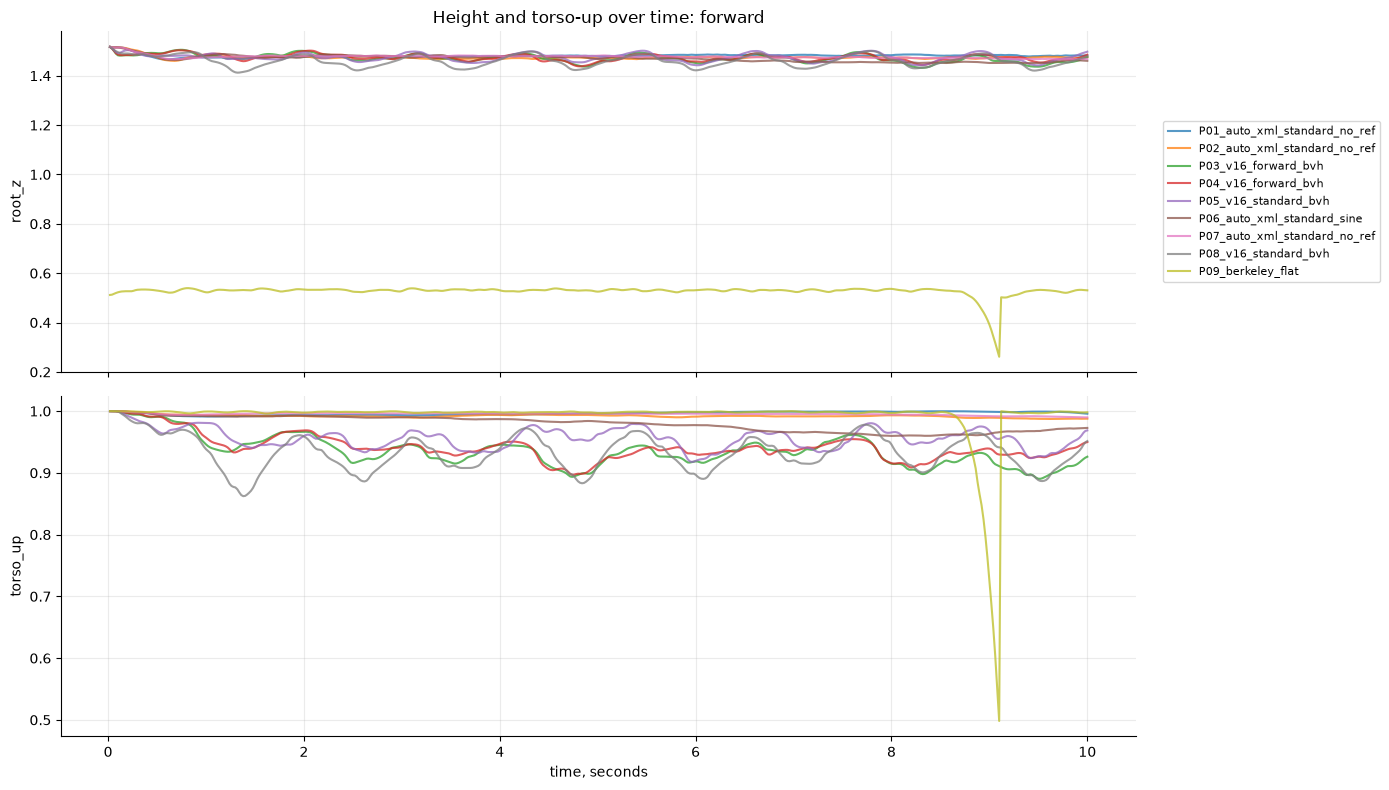

In [61]:
height_summary = (
    steps.groupby(["policy_id", "scenario", "scenario_step"], as_index=False)
    .agg(time_s=("time_s", "mean"), root_z=("root_z", "mean"), torso_up=("torso_up", "mean"))
)

selected_scenario = "forward"
subset = height_summary.loc[height_summary["scenario"].eq(selected_scenario)]
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
for policy_id, group in subset.groupby("policy_id", sort=False):
    axes[0].plot(group["time_s"], group["root_z"], alpha=0.75, label=policy_id)
    axes[1].plot(group["time_s"], group["torso_up"], alpha=0.75)
axes[0].set_title(f"Height and torso-up over time: {selected_scenario}")
axes[0].set_ylabel("root_z")
axes[1].set_ylabel("torso_up")
axes[1].set_xlabel("time, seconds")
axes[0].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8)
plt.tight_layout()
plt.show()

<!-- NOTEBOOK_TOP3_HEIGHT_POSTURE -->
### Top 3 za visinu i uspravnost na forward scenariju

| policy_id | policy_type | mean_torso_up | min_torso_up | mean_root_height | root_height_std | terminated_rate |
| --- | --- | --- | --- | --- | --- | --- |
| P01_auto_xml_standard_no_ref | biomechanics | 0.9963 | 0.9901 | 1.4809 | 0.0068 | 0.0000 |
| P07_auto_xml_standard_no_ref | biomechanics | 0.9952 | 0.9888 | 1.4770 | 0.0077 | 0.0000 |
| P09_berkeley_flat | berkeley | 0.9926 | 0.6616 | 0.5260 | 0.0219 | 0.3333 |

Zakljucak: stabilan root_z i visok torso_up znace bolji balans.


<!-- FILTERED_TOP4_HEIGHT_TORSO_NOTES -->
### Filtrirani height/torso-up: samo top 4

| policy_id | policy_type | mean_torso_up | min_torso_up | mean_root_height | root_height_std | terminated_rate |
| --- | --- | --- | --- | --- | --- | --- |
| P01_auto_xml_standard_no_ref | biomechanics | 0.9963 | 0.9901 | 1.4809 | 0.0068 | 0.0000 |
| P07_auto_xml_standard_no_ref | biomechanics | 0.9952 | 0.9888 | 1.4770 | 0.0077 | 0.0000 |
| P09_berkeley_flat | berkeley | 0.9926 | 0.6616 | 0.5260 | 0.0219 | 0.3333 |
| P02_auto_xml_standard_no_ref | biomechanics | 0.9920 | 0.9853 | 1.4747 | 0.0089 | 0.0000 |

Zakljucak: stabilan root_z i visok torso_up znace bolji balans.


,policy_id,policy_type,mean_torso_up,min_torso_up,mean_root_height,root_height_std,terminated_rate
0,P01_auto_xml_standard_no_ref,biomechanics,0.9963,0.9901,1.4809,0.0068,0.0000
6,P07_auto_xml_standard_no_ref,biomechanics,0.9952,0.9888,1.4770,0.0077,0.0000
8,P09_berkeley_flat,berkeley,0.9926,0.6616,0.5260,0.0219,0.3333
1,P02_auto_xml_standard_no_ref,biomechanics,0.9920,0.9853,1.4747,0.0089,0.0000


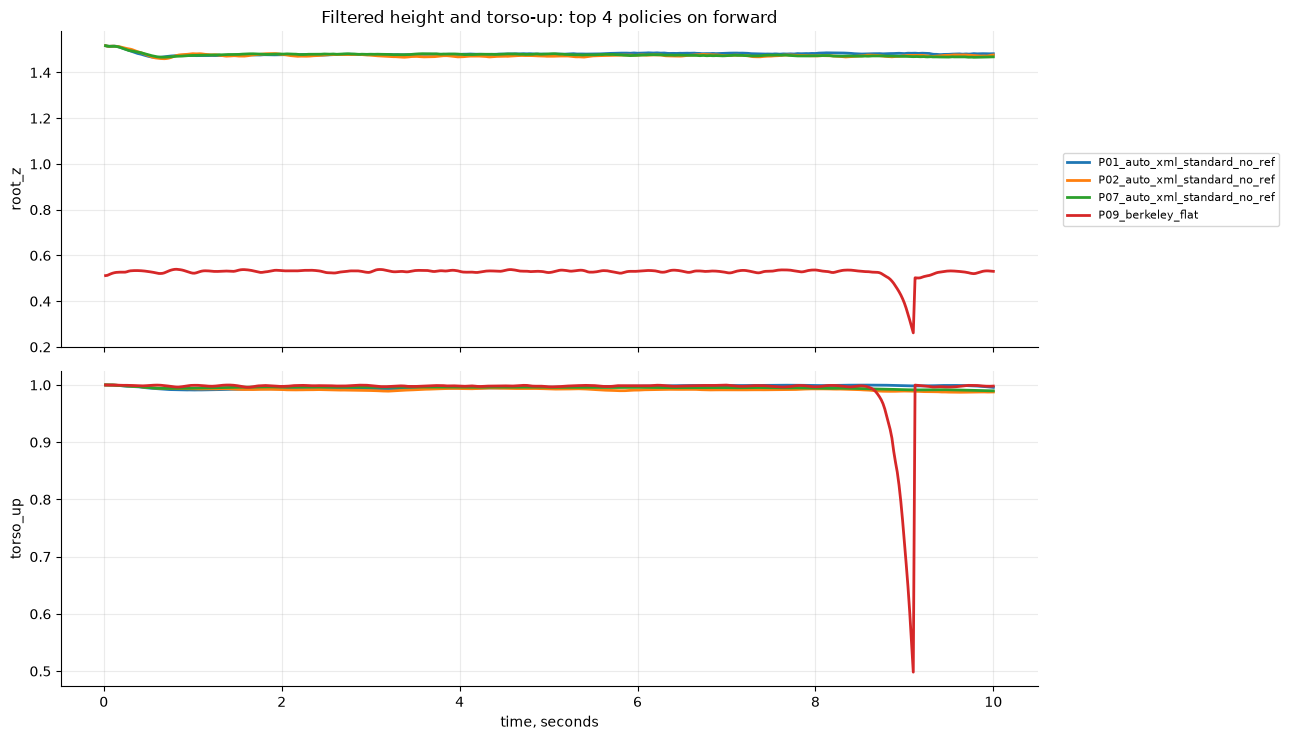

In [62]:
# Filtered height and torso-up: top 4 policies on the forward scenario.
filtered_scenario = "forward"
height_top4 = (
    episode_metrics.loc[episode_metrics["scenario"].eq(filtered_scenario)]
    .groupby(["policy_id", "policy_type"], as_index=False)
    .agg(
        mean_torso_up=("mean_torso_up", "mean"),
        min_torso_up=("min_torso_up", "mean"),
        mean_root_height=("mean_root_height", "mean"),
        root_height_std=("root_height_std", "mean"),
        terminated_rate=("terminated", "mean"),
    )
    .sort_values(["mean_torso_up", "terminated_rate", "root_height_std"], ascending=[False, True, True])
    .head(4)
)
filtered_policies = height_top4["policy_id"].tolist()
display(height_top4)

filtered_height_summary = (
    steps.loc[
        steps["scenario"].eq(filtered_scenario)
        & steps["policy_id"].isin(filtered_policies)
    ]
    .groupby(["policy_id", "scenario_step"], as_index=False)
    .agg(time_s=("time_s", "mean"), root_z=("root_z", "mean"), torso_up=("torso_up", "mean"))
)
fig, axes = plt.subplots(2, 1, figsize=(13, 7.5), sharex=True)
for policy_id, group in filtered_height_summary.groupby("policy_id", sort=False):
    axes[0].plot(group["time_s"], group["root_z"], linewidth=2.0, label=policy_id)
    axes[1].plot(group["time_s"], group["torso_up"], linewidth=2.0, label=policy_id)
axes[0].set_title(f"Filtered height and torso-up: top {len(filtered_policies)} policies on {filtered_scenario}")
axes[0].set_ylabel("root_z")
axes[1].set_ylabel("torso_up")
axes[1].set_xlabel("time, seconds")
axes[0].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=8)
plt.tight_layout()
plt.show()


## 13. Actuator analiza

In [63]:
actuator_overall = (
    actuator_metrics.groupby(["policy_id", "actuator"], as_index=False)
    .agg(
        mean_abs_action=("mean_abs_action", "mean"),
        saturation_rate=("saturation_rate", "mean"),
        motor_error_rmse=("motor_error_rmse", "mean"),
        torque_rms=("torque_rms", "mean"),
        mean_abs_power=("mean_abs_power", "mean"),
    )
)

top_power_actuators = (
    actuator_overall.sort_values("mean_abs_power", ascending=False)
    .head(25)
    .reset_index(drop=True)
)
display_table("Top actuator power hotspots", top_power_actuators, rows=25)

### Top actuator power hotspots

,policy_id,actuator,mean_abs_action,saturation_rate,motor_error_rmse,torque_rms,mean_abs_power
0,P06_auto_xml_standard_sine,right_ankle_z,0.4141,0.0360,0.1715,20.7698,39.3492
1,P02_auto_xml_standard_no_ref,right_ankle_z,0.4176,0.0440,0.1675,20.3047,39.0355
2,P05_v16_standard_bvh,right_hip_x,0.5110,0.1960,0.4965,49.6872,38.1701
3,P08_v16_standard_bvh,right_hip_x,0.4565,0.0588,0.5151,51.5972,37.2365
4,P08_v16_standard_bvh,left_knee_z,0.4325,0.0525,0.1819,18.4684,36.0073
5,P07_auto_xml_standard_no_ref,right_ankle_z,0.4368,0.0420,0.1701,20.6333,35.6169
6,P01_auto_xml_standard_no_ref,right_ankle_z,0.4709,0.0490,0.1716,20.7790,33.4813
7,P07_auto_xml_standard_no_ref,left_knee_z,0.3090,0.0000,0.4619,50.6265,32.2598
8,P04_v16_forward_bvh,right_hip_x,0.5705,0.0800,0.4525,45.3200,31.5147
9,P07_auto_xml_standard_no_ref,left_ankle_z,0.8157,0.1363,0.1466,17.4684,30.9715


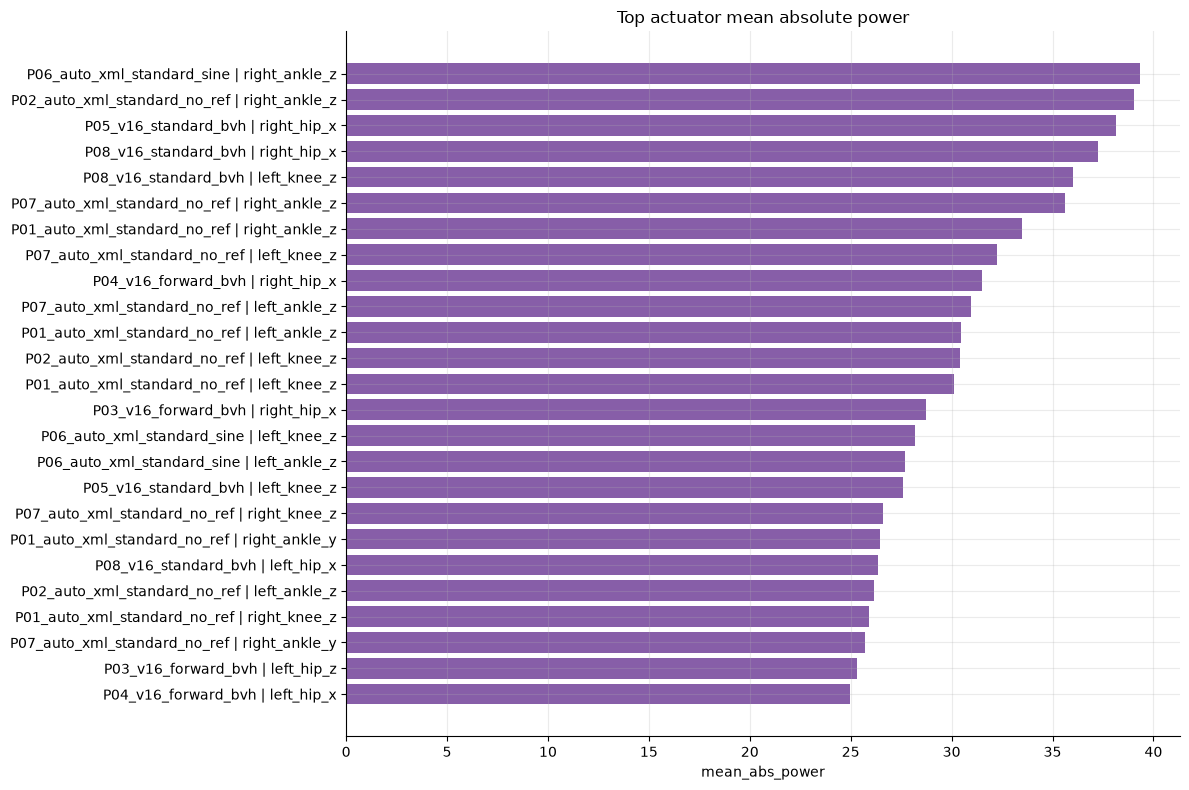

In [64]:
if not top_power_actuators.empty:
    plot_data = top_power_actuators.sort_values("mean_abs_power", ascending=True).copy()
    plot_data["label"] = plot_data["policy_id"] + " | " + plot_data["actuator"]
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.barh(plot_data["label"], plot_data["mean_abs_power"], color="#7a4c9f", alpha=0.9)
    ax.set_title("Top actuator mean absolute power")
    ax.set_xlabel("mean_abs_power")
    plt.tight_layout()
    plt.show()

<!-- NOTEBOOK_TOP3_ACTUATOR_POWER -->
### Top 3 actuator power hotspot-a

| policy_id | actuator | mean_abs_power | torque_rms | mean_abs_action | saturation_rate |
| --- | --- | --- | --- | --- | --- |
| P06_auto_xml_standard_sine | right_ankle_z | 39.3492 | 20.7698 | 0.4141 | 0.0360 |
| P02_auto_xml_standard_no_ref | right_ankle_z | 39.0355 | 20.3047 | 0.4176 | 0.0440 |
| P05_v16_standard_bvh | right_hip_x | 38.1701 | 49.6872 | 0.5110 | 0.1960 |

Zakljucak: ovde se vidi gde policy najvise trosi kontrolu.


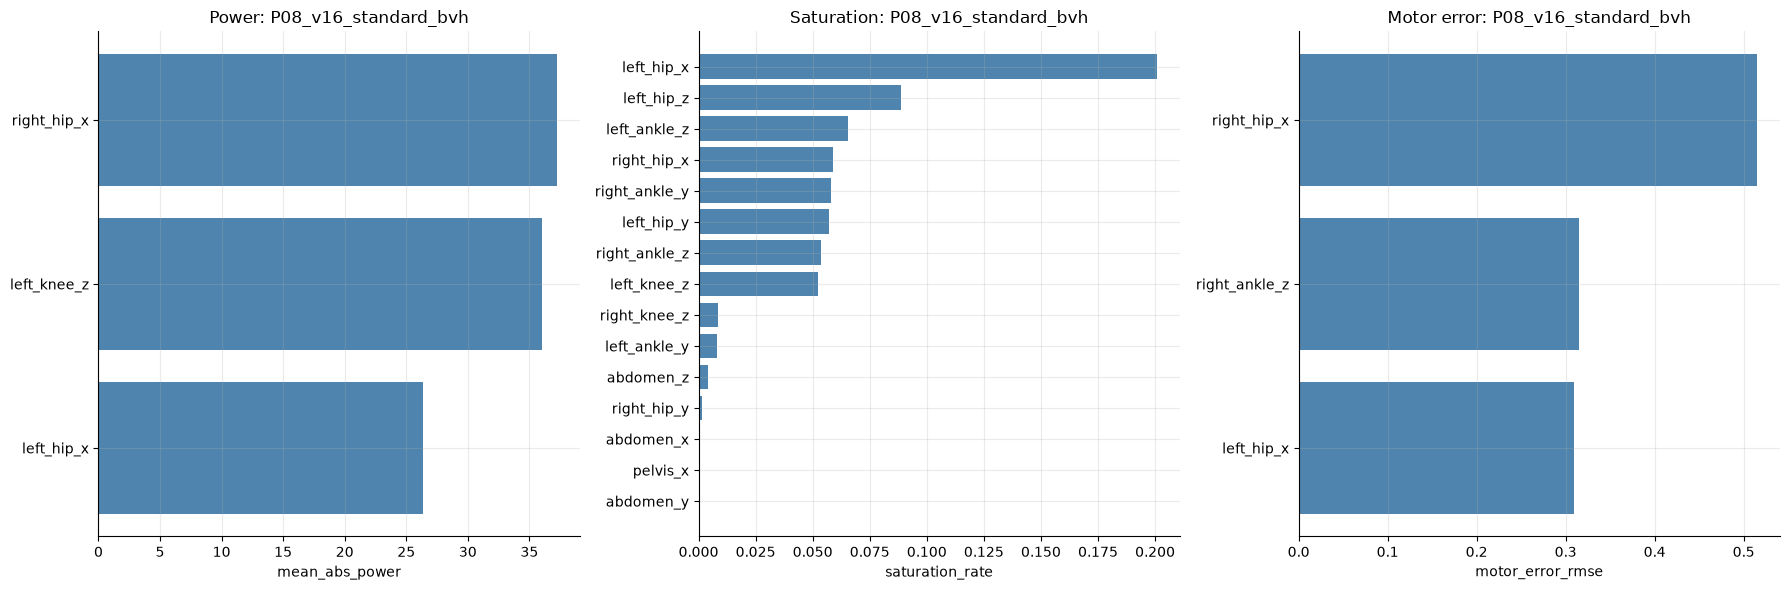

In [65]:
best_policy_id = leaderboard.iloc[0]["policy_id"] if not leaderboard.empty else actuator_overall["policy_id"].iloc[0]
best_actuators = actuator_overall.loc[actuator_overall["policy_id"].eq(best_policy_id)].sort_values("mean_abs_power", ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, metric, title in zip(
    axes,
    ["mean_abs_power", "saturation_rate", "motor_error_rmse"],
    ["Power", "Saturation", "Motor error"],
    strict=True,
):
    subset = best_actuators.sort_values(metric, ascending=True).tail(15)
    ax.barh(subset["actuator"], subset[metric], color="#2f6f9f", alpha=0.85)
    ax.set_title(f"{title}: {best_policy_id}")
    ax.set_xlabel(metric)
plt.tight_layout()
plt.show()

<!-- NOTEBOOK_TOP3_BEST_POLICY_ACTUATORS -->
### Top 3 actuator dijagnostika za najbolji policy: P08_v16_standard_bvh

| metric | actuator | value | mean_abs_power | saturation_rate | motor_error_rmse |
| --- | --- | --- | --- | --- | --- |
| mean_abs_power | right_hip_x | 37.2365 | 37.2365 | 0.0588 | 0.5151 |
| mean_abs_power | left_knee_z | 36.0073 | 36.0073 | 0.0525 | 0.1819 |
| mean_abs_power | left_hip_x | 26.3591 | 26.3591 | 0.2008 | 0.3089 |
| saturation_rate | left_hip_x | 0.2008 | 26.3591 | 0.2008 | 0.3089 |
| saturation_rate | left_hip_z | 0.0887 | 11.2896 | 0.0887 | 0.1115 |
| saturation_rate | left_ankle_z | 0.0657 | 15.0899 | 0.0657 | 0.2373 |
| motor_error_rmse | right_hip_x | 0.5151 | 37.2365 | 0.0588 | 0.5151 |
| motor_error_rmse | right_ankle_z | 0.3151 | 20.0864 | 0.0538 | 0.3151 |
| motor_error_rmse | left_hip_x | 0.3089 | 26.3591 | 0.2008 | 0.3089 |

Zakljucak: ovde se vidi gde policy najvise trosi kontrolu.


## 14. Raw rollout table explorer

Raw pregled najbitnijih step-level kolona.

In [66]:
important_step_columns = [
    "policy_id",
    "scenario",
    "seed",
    "scenario_step",
    "time_s",
    "reward",
    "done",
    "command_x",
    "command_y",
    "command_yaw",
    "measured_command_x",
    "measured_command_y",
    "measured_command_yaw",
    "command_error_norm",
    "root_x",
    "root_y",
    "root_z",
    "torso_up",
    "left_foot_contact",
    "right_foot_contact",
    "action_norm",
    "action_rate_norm",
    "mechanical_power_abs",
    "foot_slip_speed",
]
available_step_columns = [column for column in important_step_columns if column in steps.columns]
display(steps[available_step_columns].head(30))
print(f"Total rollout columns: {len(steps.columns)}")

,policy_id,scenario,seed,scenario_step,time_s,reward,done,command_x,command_y,command_yaw,measured_command_x,measured_command_y,measured_command_yaw,command_error_norm,root_x,root_y,root_z,torso_up,left_foot_contact,right_foot_contact,action_norm,action_rate_norm,mechanical_power_abs,foot_slip_speed
0,P01_auto_xml_standard_no_ref,diagonal,7,0,0.0200,-2.8313,0,0.2500,0.1500,0.2500,0.0017,0.0128,-0.0310,0.3993,0.0000,-0.0001,1.5168,1.0000,1.0000,1.0000,2.0656,0.0000,182.0118,0.0000
1,P01_auto_xml_standard_no_ref,diagonal,7,1,0.0400,-1.8380,0,0.2500,0.1500,0.2500,-0.0232,0.0613,0.1773,0.2963,-0.0003,-0.0010,1.5138,1.0000,1.0000,1.0000,2.4168,105.9543,220.0874,0.3712
2,P01_auto_xml_standard_no_ref,diagonal,7,2,0.0600,-1.7002,0,0.2500,0.1500,0.2500,-0.0097,0.1224,0.2592,0.2613,-0.0007,-0.0030,1.5114,1.0000,1.0000,1.0000,2.0112,79.6778,282.2389,0.2590
3,P01_auto_xml_standard_no_ref,diagonal,7,3,0.0800,-2.2116,0,0.2500,0.1500,0.2500,0.0157,0.1611,0.2037,0.2391,-0.0006,-0.0059,1.5113,0.9999,1.0000,1.0000,2.0369,31.4648,645.0902,0.2784
4,P01_auto_xml_standard_no_ref,diagonal,7,4,0.1000,-1.4113,0,0.2500,0.1500,0.2500,0.0319,0.1820,0.1881,0.2290,-0.0002,-0.0095,1.5119,0.9997,1.0000,1.0000,1.9217,33.5505,247.5147,0.2693
5,P01_auto_xml_standard_no_ref,diagonal,7,5,0.1200,-0.6180,0,0.2500,0.1500,0.2500,0.0456,0.1819,0.1987,0.2132,0.0005,-0.0132,1.5120,0.9992,1.0000,1.0000,1.8515,32.8896,272.0934,0.2870
6,P01_auto_xml_standard_no_ref,diagonal,7,6,0.1400,0.4415,0,0.2500,0.1500,0.2500,0.0657,0.1835,0.2002,0.1939,0.0015,-0.0168,1.5107,0.9983,1.0000,1.0000,1.8655,32.2831,224.1025,0.4718
7,P01_auto_xml_standard_no_ref,diagonal,7,7,0.1600,0.9367,0,0.2500,0.1500,0.2500,0.0868,0.1946,0.1725,0.1861,0.0030,-0.0205,1.5083,0.9971,1.0000,1.0000,1.7414,32.8556,121.2399,0.3902
8,P01_auto_xml_standard_no_ref,diagonal,7,8,0.1800,0.7866,0,0.2500,0.1500,0.2500,0.0996,0.1963,0.2007,0.1649,0.0047,-0.0242,1.5044,0.9957,1.0000,1.0000,1.7450,26.0075,133.6769,0.3415
9,P01_auto_xml_standard_no_ref,diagonal,7,9,0.2000,1.4662,0,0.2500,0.1500,0.2500,0.1239,0.2018,0.1979,0.1460,0.0067,-0.0281,1.5005,0.9942,1.0000,1.0000,1.8154,28.5536,182.0637,0.3188


Total rollout columns: 469


In [67]:
prefix_counts = []
for prefix in ["qpos_", "qvel_", "joint_pos_", "joint_vel_", "action_", "motor_target_", "motor_error_", "torque_", "power_", "env_metric_", "info_"]:
    prefix_counts.append({"prefix": prefix, "columns": sum(column.startswith(prefix) for column in steps.columns)})
pd.DataFrame(prefix_counts)

,prefix,columns
0,qpos_,40
1,qvel_,39
2,joint_pos_,45
3,joint_vel_,45
4,action_,36
5,motor_target_,31
6,motor_error_,30
7,torque_,30
8,power_,30
9,env_metric_,44


## 15. Export dodatnih notebook tabela

In [ ]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

leaderboard.to_csv(OUTPUT_DIR / "notebook_in_distribution_leaderboard.csv", index=False)
overall_scenario_score.to_csv(OUTPUT_DIR / "notebook_overall_scenario_score.csv", index=False)
scenario_leaders.to_csv(OUTPUT_DIR / "notebook_scenario_top3.csv", index=False)
top_power_actuators.to_csv(OUTPUT_DIR / "notebook_top_power_actuators.csv", index=False)

print(f"Saved notebook summary CSVs to: {OUTPUT_DIR}")

Saved notebook summary CSVs to: c:\Users\aleks\Desktop\Aleksie kerefeke\master\RS projekat - RL politika ucenja joystick\mujoco-bipedal-joystick-walker\analysis_outputs


: 

## 16. Zakljucak

Najbitnije za citanje rezultata:

1. Prvo gledaj `composite_score`.
2. Zatim proveri survival/falls.
3. Onda tracking RMSE.
4. Na kraju gledaj trajectory, height/torso-up i actuator power.
